<a href="https://colab.research.google.com/github/falseywinchnet/EpistemicGPT/blob/main/EPISTEMICGPT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
os.environ["TORCHINDUCTOR_FREEZE_PCH"] = "1"
# Also force Inductor to use a fresh directory if the previous one is locked
os.environ["TORCHINDUCTOR_CACHE_DIR"] = "/tmp/torch_compile_fresh"

In [ ]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"


In [66]:
#dedicated to the public domain for the glory of god.
#Baruch kevod elohei shamayim ha-elyonim mimkomo
#Eloheinu shebashamayim yached shimcha v'kayeim malchutecha tamid umloch aleinu le'olam va'ed
#2026 joshuah.rainstar@gmail.com

#Version 2.6 EpistemicGPT
#im already forgetting half of what ive done here... lol!

import math
import copy
from dataclasses import dataclass
from typing import Optional, Tuple, List
import torch
import torch.nn as nn
import torch.nn.functional as F

def make_boundary_ste_hook(alpha=1.0):
    def hook(module, grad_input, grad_output):
        if not grad_input or not grad_output:
            return None

        gi = grad_input[0]
        go = grad_output[0]

        if gi is None or go is None:
            return None
        if gi.shape != go.shape:
            return None

        new_gi = alpha * go + (1.0 - alpha) * gi
        return (new_gi,) + tuple(grad_input[1:])
    return hook


class LELU(nn.Module):
    def __init__(self):
        super().__init__()
        self.scale = math.pi / math.sqrt(3.0) #logistic CDF matched scale beats gelu and is less expensive

    def forward(self, x):
        return x * torch.sigmoid(self.scale * x)

"""
CylinderRoPE: exact circular rotary position embeddings.

The contract
------------
Three properties define the problem:

  P1 (isometry)     <R(p) q, R(p) k> = <q, k>          no dot-product distortion
  P2 (relativity)   <R(p) q, R(p') k> depends only on  p - p'   every position is
                    the head of the line relative to its own history
  P3 (circularity)  R(p + m) = R(p) exactly            circumference m, set once

P1 forces R(p) in O(D). P2 forces R(p)^T R(p') = F(p - p') and F is then a group
homomorphism: F(a + b) = F(a) F(b), F(0) = I. P3 makes F a homomorphism from the
cyclic group Z_m into O(D).

The classification theorem (real representation theory of Z_m, Peter-Weyl for
finite abelian groups): every such F is, in some fixed orthonormal basis P, a
block-diagonal sum of 2x2 rotations by angles 2*pi*k_j/m with k_j integers,
plus possibly trivial (frozen) and sign (period-2) one-dimensional blocks. The
basis P is gauge: it is absorbed by the learned projections W_q and W_k that sit
immediately upstream. Therefore the entire solution space of the contract is
RoPE whose frequencies live on the integer lattice 2*pi*Z/m. Nothing else
exists. The remaining design freedom, and it is the whole game, is the multiset
of D/2 integers {k_j}.

Why decay cannot live inside the cylinder: P2 + P3 give F(1)^m = I even without
P1, so F(1) has finite order, all eigenvalues are roots of unity, and F(1) is
semisimple. No direction contracts. Forgetting is mathematically exiled to the
attention mask and to whatever consolidates the past. That division of labor is
forced, not stylistic.

Aliasing bounds: with a causal sliding window of width w, visible offsets lie in
[0, w]. Two visible keys collide only if their offsets are congruent mod m, so
the hard requirement is w <= m - 1. The cosine (symmetric) component of the
kernel satisfies g(d) = g(m - d), so resolution of the symmetric part degrades
approaching m/2; the sine component keeps directionality but w <= m/2 is the
comfortable regime. Recommended: m >= 2w, and on-the-fly mode makes large m free.

Kernel design: the positional prior is the kernel
    g(d) = (2/D) * sum_j cos(2*pi*k_j*d/m),
the positive-definite functions on Z_m realizable with integer multiplicities
(Herglotz/Bochner: nonnegative spectral weights; here weights are quantized to
plane counts). Because the mask hides every offset beyond w, the band
(w, m - w) is a genuine don't-care region, a luxury classical window design does
not have, so concentration on [0, w] can be much sharper than any full-period
design. design='pursuit' runs a greedy unit-amplitude matching pursuit over the
harmonic dictionary restricted to [0, w]: each rotation plane contributes
exactly one unit cosine, so the pursuit selects the multiset directly,
multiplicities emerging as repeated picks. design='snap' and
design='snap_sigmoid' project a known-good continuous spectrum (log-spaced, or
the two-sided sigmoidal logspace) onto the lattice with no loss of intent.

Exactness properties bought:
  * The group action is transitive: there is no positional observable except the
    masked offset. Length generalization is exact at the encoding level.
  * KV cache entries are rotated once and are valid forever. No re-anchoring,
    no re-rotation of cached keys, ever.
  * Phases are computed by integer modular arithmetic: (p * k) mod m in int64,
    then one float multiply. Position 10**15 has bit-exact phase where vanilla
    RoPE in fp32 has already shed all low-frequency precision.

Usage
-----
    rope = CylinderRoPE(dim=head_dim, m=8192, window=4096)
    q = rope(q, positions)   # positions: absolute int64 token counter, any size
    k = rope(k, positions)   # attention owns the counter and the mask;
                             # rope owns the wrap. Mask offsets > window.

positions may be shape (T,) or (B, T). x is (B, H, T, D).
"""

import math
import warnings
from functools import reduce

import torch
import torch.nn as nn


# ----------------------------------------------------------------------------
# target kernels for pursuit design (defined on offsets d = 0 .. window)
# ----------------------------------------------------------------------------

def hann_target(window: int, height: float) -> torch.Tensor:
    d = torch.arange(window + 1, dtype=torch.float64)
    return height * 0.5 * (1.0 + torch.cos(math.pi * d / window))


def exp_target(window: int, height: float, tau: float) -> torch.Tensor:
    d = torch.arange(window + 1, dtype=torch.float64)
    return height * torch.exp(-d / tau)


def spike_plus_tail_target(window: int, height: float,
                           spike_frac: float = 0.35,
                           tau: float = None) -> torch.Tensor:
    """Sharp local-resolution spike at d=0 riding on a slow Hann tail across the
    window. Mimics the shape of empirically successful RoPE kernels."""
    if tau is None:
        tau = max(1.0, window / 48.0)
    return (spike_frac * exp_target(window, height, tau)
            + (1.0 - spike_frac) * hann_target(window, height))


# ----------------------------------------------------------------------------
# harmonic multiset designs
# ----------------------------------------------------------------------------

def design_pursuit(dim_half: int, m: int, window: int,
                   target: torch.Tensor = None) -> list:
    """Greedy unit-amplitude matching pursuit over integer harmonics
    k in [1, m//2 - 1]. Fits sum_j cos(2*pi*k_j*d/m) to `target` on
    d in [0, window] only; the masked band is don't-care. Returns a sorted
    list of dim_half integers, repeats allowed (multiplicity = weight)."""
    assert m >= 6 and 1 <= window <= m - 1
    if target is None:
        target = spike_plus_tail_target(window, float(dim_half))
    target = target.to(torch.float64)
    assert target.numel() == window + 1

    K = m // 2 - 1  # usable harmonics: 1 .. K (exclude DC and the sign rep)

    # ||a_k||^2 over the window, via one FFT of the window indicator:
    # sum_{d=0..w} cos^2(2 pi k d / m) = (w+1)/2 + (1/2) Re S[2k mod-folded]
    ind = torch.zeros(m, dtype=torch.float64)
    ind[: window + 1] = 1.0
    ReS = torch.fft.rfft(ind).real                      # bins 0 .. m//2
    ks = torch.arange(1, K + 1)
    fold = torch.where(2 * ks <= m // 2, 2 * ks, m - 2 * ks)
    atom_n2 = (window + 1) / 2.0 + 0.5 * ReS[fold]

    residual = torch.zeros(m, dtype=torch.float64)
    residual[: window + 1] = target
    d = torch.arange(window + 1, dtype=torch.float64)

    chosen = []
    for _ in range(dim_half):
        # correlation of residual (supported on the window) with every atom,
        # all bins at once: Re rfft(residual)[k] = sum_d r(d) cos(2 pi k d / m)
        corr = torch.fft.rfft(residual).real[1: K + 1]
        scores = 2.0 * corr - atom_n2                   # squared-error reduction
        k = int(torch.argmax(scores).item()) + 1
        chosen.append(k)
        residual[: window + 1] -= torch.cos(2 * math.pi * k * d / m)
    return sorted(chosen)


def design_snap(dim_half: int, m: int,
                w_min: float = None, w_max: float = math.pi / 2) -> list:
    """Log-spaced spectrum snapped to the lattice. Defaults: highest frequency
    pi/2 (one rotation per four tokens), lowest 2*pi/m (k = 1, one rotation per
    circumference)."""
    if w_min is None:
        w_min = 2 * math.pi / m
    if dim_half == 1:
        omegas = torch.tensor([math.sqrt(w_min * w_max)], dtype=torch.float64)
    else:
        omegas = torch.logspace(math.log10(w_max), math.log10(w_min),
                                dim_half, dtype=torch.float64)
    k = torch.round(omegas * m / (2 * math.pi)).long().clamp(1, m // 2 - 1)
    return sorted(k.tolist())


def design_snap_sigmoid(dim_half: int, m: int,
                        w_min: float = None, w_max: float = math.pi / 2,
                        base: float = 10.0) -> list:
    """The two-sided sigmoidal logspace (mass piled at both spectral ends,
    sparse middle), snapped to the lattice. Ports the tuned spectrum losslessly
    in intent; the lattice supplies the exact circularity."""
    if w_min is None:
        w_min = 2 * math.pi / m
    n_hi = dim_half // 2
    n_lo = dim_half - n_hi
    hi = torch.logspace(math.log(w_min, base), math.log(w_max, base),
                        n_hi, base=base, dtype=torch.float64)
    lo = w_max - torch.logspace(math.log(w_min, base), math.log(w_max, base),
                                n_lo + 1, base=base, dtype=torch.float64)[:-1]
    omegas = torch.cat([hi, lo])
    k = torch.round(omegas * m / (2 * math.pi)).long().clamp(1, m // 2 - 1)
    return sorted(k.tolist())


def wrapped_exponential_spectrum(m: int, taus, weights,
                                 dc_frac: float) -> torch.Tensor:
    """Fourier weights on Z_m of f(d) = dc + (1-dc) * sum_i w_i exp(-dist/tau_i)
    with dist the circular distance. Each exponential wraps to a Poisson kernel
    whose Fourier coefficients are strictly positive (Herglotz), so the mixture
    is positive definite with a fully positive spectrum. Returns the per-
    harmonic amplitude weights v[k] for k = 0 .. m//2 - 1 (k = 0 is the DC /
    frozen-plane mass), normalized so sum(v) ~= f(0) = 1."""
    d = torch.arange(m, dtype=torch.float64)
    dist = torch.minimum(d, m - d)
    w = torch.tensor(weights, dtype=torch.float64)
    w = w / w.sum()
    f = torch.zeros(m, dtype=torch.float64)
    for wi, tau in zip(w.tolist(), taus):
        f += wi * torch.exp(-dist / tau)
    f = dc_frac + (1.0 - dc_frac) * f
    c = torch.fft.rfft(f).real / m
    v = torch.cat([c[:1], 2.0 * c[1: m // 2]])     # k = 0 .. m//2 - 1
    return v.clamp_min(0.0)


def _equal_mass_atoms(v: torch.Tensor, n: int) -> list:
    """Deterministic equal-mass quantization of a nonnegative spectral measure
    into n unit atoms: place atom i at the ((i + 0.5)/n)-quantile of the
    spectral CDF. Compact mass reproduces multiplicities; heavy tails get
    stratified single atoms instead of being truncated, which is what unit-
    amplitude planes require."""
    cdf = torch.cumsum(v, dim=0)
    cdf = cdf / cdf[-1]
    targets = (torch.arange(n, dtype=torch.float64) + 0.5) / n
    idx = torch.searchsorted(cdf, targets)
    return idx.clamp(0, v.numel() - 1).tolist()


def design_poisson(dim_half: int, m: int, window: int,
                   taus=None, weights=None, dc_frac: float = 0.09,
                   target_kernel: torch.Tensor = None) -> list:
    """Bernstein-class kernel design. Completely monotone kernels, the smooth
    nonnegative monotone decays with no zero crossing, are exactly mixtures of
    exponentials (Bernstein/Hausdorff); each exponential wraps on Z_m to a
    Poisson kernel with strictly positive Fourier weights. Quantizing that
    spectrum to dim_half unit-amplitude planes by largest remainder yields a
    multiset whose kernel tracks the mixture by construction: g(d) ~= dc
    + (1-dc) * sum_i w_i exp(-d/tau_i), with the dc mass realized as frozen
    (position-free) planes, i.e., partial rotary derived rather than assumed,
    and acting as a hard positive floor under quantization ripple.
    Defaults: a short component for local resolution and a long component
    matching an exp(-pi d / window) envelope across the window."""
    if taus is None:
        taus = (3.0, window / math.pi)
    if weights is None:
        weights = (0.25, 0.75)
    v = wrapped_exponential_spectrum(m, taus, weights, dc_frac)
    return sorted(_equal_mass_atoms(v, dim_half))


def _dither_order(n: int) -> list:
    """The fold-shuffle permutation of plane assignment. At the kernel level
    this is conjugation by a permutation matrix, hence gauge; it is kept because
    plane assignment can matter to optimizer dynamics."""
    order = list(range(n))
    if n >= 4:
        for _ in range(int(math.log2(n)) - 1):
            order = order[0::2] + order[1::2]
    return order


# ----------------------------------------------------------------------------
# the module
# ----------------------------------------------------------------------------

class CylinderRoPE(nn.Module):
    """Rotary embeddings on the cyclic group Z_m. Drop-in for rotary application
    sites; keeps the split-half dual convention (first half of dims uses the
    conjugate rotation direction, second half the standard one) for
    compatibility. Note on that convention: for a fixed anisotropic pair q != k
    the per-plane logit is S*cos(w d) + sigma*A*sin(w d) with S the symmetric
    and A the antisymmetric pairing of the plane components and sigma = +-1 the
    direction convention. Flipping sigma flips the phase of every plane,
    phi -> -phi in r*cos(w d - sigma*phi), and changes the interference pattern
    and therefore the match SNR for fixed content. The conventions are
    equivalent only modulo a relearning of W_q, W_k (b -> -b in those planes),
    i.e., the achievable set is identical but no fixed-input kernel is.

    Parameters
    ----------
    dim     : head dimension D (multiple of 4 under the split-half convention)
    m       : circumference. R(p + m) = R(p) exactly. Hard floor: window + 1.
              Recommended: >= 2 * window. Large m is free in on-the-fly mode.
    window  : sliding attention window the mask will enforce. Used for kernel
              design and for the aliasing guard. Defaults to m // 2.
    design  : 'pursuit' | 'snap' | 'snap_sigmoid' | 'explicit'
    harmonics : explicit multiset of dim//2 integers when design='explicit'
    target  : optional pursuit target on d = 0..window (tensor, length window+1)
    dither  : apply the fold-shuffle to plane assignment (default True)
    split_half_convention : keep the dual h1-conjugate / h2-standard layout
    cache_limit_bytes : precompute the full (m, dim//2) phase table when it fits;
              otherwise compute phases on the fly with exact int64 modular
              arithmetic. Both paths are bit-identical in result.
    """

    def __init__(self, dim: int, m: int, window: int = None,
                 design: str = 'pursuit', harmonics: list = None,
                 target: torch.Tensor = None,
                 w_min: float = None, w_max: float = math.pi / 2,
                 dither: bool = True, split_half_convention: bool = True,
                 cache_limit_bytes: int = 256 * 2 ** 20):
        super().__init__()
        if split_half_convention:
            assert dim % 4 == 0, "split-half convention needs dim % 4 == 0"
        else:
            assert dim % 2 == 0
        m = int(m)
        assert m >= 6
        if window is None:
            window = m // 2
        assert 1 <= window <= m - 1, "hard aliasing bound: window <= m - 1"
        if window > m // 2:
            warnings.warn("window > m/2: the symmetric kernel component "
                          "satisfies g(d) = g(m-d); resolution degrades near "
                          "m/2. Prefer m >= 2*window.")
        self.dim, self.m, self.window = dim, m, window
        self.split_half_convention = split_half_convention
        n = dim // 2

        if design == 'explicit':
            assert harmonics is not None and len(harmonics) == n
            ks = [int(k) for k in harmonics]
            assert all(0 <= k <= m - 1 for k in ks)
        elif design == 'pursuit':
            ks = design_pursuit(n, m, window, target)
        elif design == 'poisson':
            ks = design_poisson(n, m, window)
        elif design == 'snap':
            ks = design_snap(n, m, w_min, w_max)
        elif design == 'snap_sigmoid':
            ks = design_snap_sigmoid(n, m, w_min, w_max)
        else:
            raise ValueError(design)

        nz = [k for k in ks if k > 0]
        g = reduce(math.gcd, nz, m) if nz else m
        if g > 1:
            warnings.warn(f"gcd(harmonics, m) = {g}: effective circumference "
                          f"is m/{g} = {m // g}, not m.")
        self.effective_period = m // g

        ks_sorted = sorted(ks, reverse=True)
        if dither:
            order = _dither_order(n)
            ks_final = [ks_sorted[i] for i in order]
        else:
            ks_final = ks_sorted
        self.register_buffer('harmonics',
                             torch.tensor(ks_final, dtype=torch.int64))

        table_bytes = m * n * 2 * 4
        self.cached = table_bytes <= cache_limit_bytes
        if self.cached:
            p = torch.arange(m, dtype=torch.int64)
            phase = (p[:, None] * self.harmonics[None, :]) % m   # exact int64
            ang = phase.to(torch.float64) * (2 * math.pi / m)
            self.register_buffer('cos_cached', ang.cos().to(torch.float32))
            self.register_buffer('sin_cached', ang.sin().to(torch.float32))

    # -- phase lookup ---------------------------------------------------------

    def _cos_sin(self, positions: torch.Tensor):
        """positions: int64, shape (T,) or (B, T), any magnitude (also negative;
        Python-style modulo wraps correctly). Returns cos, sin broadcastable
        against (B, H, T, D//2)."""
        idx = positions.to(torch.int64) % self.m
        if self.cached:
            cos = self.cos_cached[idx]
            sin = self.sin_cached[idx]
        else:
            phase = (idx.unsqueeze(-1) * self.harmonics) % self.m   # exact
            ang = phase.to(torch.float64) * (2 * math.pi / self.m)
            cos = ang.cos().to(torch.float32)
            sin = ang.sin().to(torch.float32)
        if positions.dim() == 1:
            cos, sin = cos[None, None], sin[None, None]          # (1,1,T,n)
        elif positions.dim() == 2:
            cos, sin = cos[:, None], sin[:, None]                # (B,1,T,n)
        else:
            raise ValueError("positions must be (T,) or (B, T)")
        return cos, sin

    # -- application ----------------------------------------------------------

    def forward(self, x: torch.Tensor, positions: torch.Tensor = None):
        """x: (B, H, T, D). positions: absolute token counter; the caller
        (attention) owns it. Defaults to arange(T) when omitted."""
        if positions is None:
            positions = torch.arange(x.shape[-2], device=x.device)
        cos, sin = self._cos_sin(positions)
        cos, sin = cos.to(x.dtype), sin.to(x.dtype)

        if not self.split_half_convention:
            a, b = x[..., 0::2], x[..., 1::2]
            out_a = a * cos - b * sin
            out_b = a * sin + b * cos
            return torch.stack([out_a, out_b], dim=-1).flatten(-2)

        D = x.shape[-1]
        mid = D // 2
        h1, h2 = x[..., :mid], x[..., mid:]
        h1_a, h1_b = h1[..., 0::2], h1[..., 1::2]
        h2_a, h2_b = h2[..., 0::2], h2[..., 1::2]

        npp = mid // 2                                   # pairs per half
        cos1, sin1 = cos[..., :npp], sin[..., :npp]
        cos2, sin2 = cos[..., npp:], sin[..., npp:]

        out_h1_a = h1_a * cos1 + h1_b * sin1             # conjugate direction
        out_h1_b = -h1_a * sin1 + h1_b * cos1
        out_h2_a = h2_a * cos2 - h2_b * sin2             # standard direction
        out_h2_b = h2_a * sin2 + h2_b * cos2

        out_h1 = torch.stack([out_h1_a, out_h1_b], dim=-1).flatten(-2)
        out_h2 = torch.stack([out_h2_a, out_h2_b], dim=-1).flatten(-2)
        return torch.cat([out_h1, out_h2], dim=-1)

    @torch.no_grad()

    def average_orbit(self, x: torch.Tensor) -> torch.Tensor:
        """
        Project x to the circumcenter / orbit-average of the CylinderRoPE action.

            P x = (1/m) sum_p R(p) x

        Nonzero harmonic planes vanish. k=0 planes survive.
        This is the mathematically correct axis projection for accumulator slots.
        """
        h = (self.harmonics % self.m) == 0

        if not self.split_half_convention:
            mask = h.to(dtype=x.dtype, device=x.device).view(*([1] * (x.dim() - 1)), -1)
            a = x[..., 0::2] * mask
            b = x[..., 1::2] * mask
            return torch.stack([a, b], dim=-1).flatten(-2)

        D = x.shape[-1]
        mid = D // 2
        h1, h2 = x[..., :mid], x[..., mid:]

        npp = mid // 2

        mask1 = h[:npp].to(dtype=x.dtype, device=x.device).view(*([1] * (x.dim() - 1)), -1)
        mask2 = h[npp:].to(dtype=x.dtype, device=x.device).view(*([1] * (x.dim() - 1)), -1)

        h1_a = h1[..., 0::2] * mask1
        h1_b = h1[..., 1::2] * mask1
        h2_a = h2[..., 0::2] * mask2
        h2_b = h2[..., 1::2] * mask2

        out_h1 = torch.stack([h1_a, h1_b], dim=-1).flatten(-2)
        out_h2 = torch.stack([h2_a, h2_b], dim=-1).flatten(-2)

        return torch.cat([out_h1, out_h2], dim=-1)

    # -- diagnostics ----------------------------------------------------------

    @torch.no_grad()
    def step_displacement(self, plane_energy: torch.Tensor = None) -> float:
        """||R(p+1) x - R(p) x|| / ||x||, which is independent of p because the
        action is isometric: consecutive positions are equidistant points on the
        orbit. This, not the slope of any single scalar projection, is the
        invariant measure of per-step distinguishability. plane_energy: optional
        per-plane energy fractions of x (defaults to isotropic)."""
        w = 2 * math.pi * self.harmonics.to(torch.float64) / self.m
        per_plane = 2.0 * (1.0 - torch.cos(w))
        if plane_energy is None:
            return float(per_plane.mean().sqrt())
        e = plane_energy.to(torch.float64)
        return float((e / e.sum() * per_plane).sum().sqrt())

    @torch.no_grad()
    def relative_kernel(self, d: torch.Tensor = None) -> torch.Tensor:
        """g(d) = E[<R(p+d) q, R(p) q>] / E[|q|^2] for isotropic q: the mean
        cosine over planes. The positional prior the model trains against."""
        if d is None:
            d = torch.arange(min(self.m, 4 * self.window + 1))
        d = d.to(torch.int64) % self.m
        phase = (d[:, None] * self.harmonics.cpu()) % self.m
        ang = phase.to(torch.float64) * (2 * math.pi / self.m)
        return ang.cos().mean(dim=1)

    @torch.no_grad()
    def directional_kernel(self, d: torch.Tensor = None) -> torch.Tensor:
        """Mean sine over planes: the antisymmetric component that gives
        before/after orientation to anisotropic q, k."""
        if d is None:
            d = torch.arange(min(self.m, 4 * self.window + 1))
        d = d.to(torch.int64) % self.m
        phase = (d[:, None] * self.harmonics.cpu()) % self.m
        ang = phase.to(torch.float64) * (2 * math.pi / self.m)
        return ang.sin().mean(dim=1)


def sliding_window_mask(q_pos: torch.Tensor, k_pos: torch.Tensor,
                        window: int) -> torch.Tensor:
    """Boolean mask, True = attend. Causal sliding window on absolute counters:
    attend iff 0 <= q_pos - k_pos <= window. This is the entire anti-resonance
    mechanism: it hides every aliased copy of the kernel."""
    d = q_pos[:, None] - k_pos[None, :]
    return (d >= 0) & (d <= window)


class RoPE(nn.Module):
    def __init__(self, dim, max_len=4096):
        super().__init__()
        self.dim = dim
        self.max_len = max_len

        w_max = torch.pi / 2 #highest frequency- one rotation in 4 tokens
        w_min = torch.pi / (max_len) #this sets the lowest scale to that sufficient to resolve needle at depth.
        #most effectively, set your context size to more than you ever intend to handle
        B = 10
        setfreqs_hi = torch.logspace(
                    start=math.log(w_min,B),
                    end=math.log(w_max,B),
                    steps=(dim // 4),
                    base=B
                )


        setfreqs_lo = w_max - torch.logspace(
            start=math.log(w_min,B),
            end=math.log(w_max,B),
            steps=(dim // 4) + 1,
            base=B
        )[:-1] # Drop last to match size and allow a smooth continuation

                # Combine
        setfreqs = torch.cat((setfreqs_hi, setfreqs_lo))
        inv_freq, _ = torch.sort(setfreqs,descending=True) #this give us a sigmoidal distribution of frequencies.
        #many large, many small, few near the midpoint.

        num_freqs = dim // 2
        num_shuffles = int(math.log2(num_freqs)) - 1 #this gives us much more optimal behavior


        for _ in range(num_shuffles): #spectral dithering
            inv_freq = torch.cat((inv_freq[0::2], inv_freq[1::2]))

        t = torch.arange(max_len).float()
        freqs = torch.einsum('i,j->ij', t, inv_freq)
        self.register_buffer('cos_cached', freqs.cos())
        self.register_buffer('sin_cached', freqs.sin())

    def get_embeddings(self, positions, device):
            # fast path: contiguous 0..T-1 positions
            if positions.ndim == 1 and positions.numel() > 0:
                expected = torch.arange(positions.numel(), device=positions.device)
                if torch.equal(positions, expected):
                    T = positions.numel()
                    cos = self.cos_cached[:T].unsqueeze(0).unsqueeze(0)
                    sin = self.sin_cached[:T].unsqueeze(0).unsqueeze(0)
                    return cos, sin

            positions = positions.clamp(0, self.max_len - 1).long()
            cos = F.embedding(positions, self.cos_cached).unsqueeze(0).unsqueeze(0)
            sin = F.embedding(positions, self.sin_cached).unsqueeze(0).unsqueeze(0)
            return cos, sin

    def forward(self, x, positions=None):
        # x: (B, H, T, D) where D = self.dim (head_dim)
        if positions is None:
            T = x.shape[-2]
            positions = torch.arange(T, device=x.device)

        cos, sin = self.get_embeddings(positions, x.device)
        # cos, sin: [1, 1, T, D//2]

        D = x.shape[-1]
        mid = D // 2
        h1 = x[..., :mid]   # first half of dimensions
        h2 = x[..., mid:]   # second half of dimensions

        # Adjacent pairing within each half:
        # h1 pairs: (h1[0],h1[1]), (h1[2],h1[3]), ...
        # h2 pairs: (h2[0],h2[1]), (h2[2],h2[3]), ...
        #
        # h1 gets sign-flipped convention (sin term adds instead of subtracts)
        # h2 gets standard convention
        #
        # This is achieved by negating the "b" element of each pair in h1
        # before feeding into the standard rotation formula.

        # For h1: negate odd-indexed elements, apply rotation, un-negate
        # Equivalent to: the kernel contribution for h1 pairs becomes
        #   S * cos(w*d) + A * sin(w*d)
        # instead of
        #   S * cos(w*d) - A * sin(w*d)

        # Extract paired elements for h1
        h1_a = h1[..., 0::2]   # even indices (the "real" part)
        h1_b = h1[..., 1::2]   # odd indices (the "imaginary" part)

        # Extract paired elements for h2
        h2_a = h2[..., 0::2]
        h2_b = h2[..., 1::2]

        # Split cos/sin for the two halves' frequency ranges
        # First D//4 frequencies go to h1, last D//4 to h2
        n_pairs_per_half = mid // 2  # D//4
        cos1 = cos[..., :n_pairs_per_half]
        sin1 = sin[..., :n_pairs_per_half]
        cos2 = cos[..., n_pairs_per_half:]
        sin2 = sin[..., n_pairs_per_half:]

        # H1: flipped convention (negate b before rotation)
        # Standard rotation on (a, -b):
        #   out_a = a * cos - (-b) * sin = a * cos + b * sin
        #   out_b_neg = a * sin + (-b) * cos = a * sin - b * cos
        # Then un-negate b: out_b = -(a * sin - b * cos) = -a * sin + b * cos
        out_h1_a = h1_a * cos1 + h1_b * sin1
        out_h1_b = -h1_a * sin1 + h1_b * cos1

        # H2: standard convention
        #   out_a = a * cos - b * sin
        #   out_b = a * sin + b * cos
        out_h2_a = h2_a * cos2 - h2_b * sin2
        out_h2_b = h2_a * sin2 + h2_b * cos2

        # Reassemble: interleave a,b back into adjacent pairs
        out_h1 = torch.stack([out_h1_a, out_h1_b], dim=-1).flatten(-2)
        out_h2 = torch.stack([out_h2_a, out_h2_b], dim=-1).flatten(-2)

        return torch.cat([out_h1, out_h2], dim=-1)



class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.act = LELU()
        self.c_fc  = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)

        self.c_proj  = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.act(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x

class MLP_bottle(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd,  config.n_embd//2, bias=config.bias)
        self.act = LELU()
        self.c_proj  = nn.Linear(config.n_embd//2, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.act(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x

def sharp_softplus(x):
    """
    Softplus above tau (keep the lazy/linear regime).
    Below tau: double-exponential suppression.

    For x >= tau: softplus(x) as normal.
    For x < tau:  sigmoid(tau) * exp(-exp(tau - x) + 1)

    This gives:
    - Continuity at tau (both sides = softplus(tau))
    - C1 continuity (derivatives match at tau)
    - Sub-threshold scores get crushed by double exponential
    - The gradient in the kill zone is FAT: the model gets strong signal
      for "push this score lower" exactly where softplus gradient vanishes

    The double exp means:
      x = tau - 0 -> ~softplus(tau)  (smooth transition)
      x = tau - 1 -> very small
      x = tau - 2 -> essentially zero
      x = tau - 3 -> hard zero

    Meanwhile the gradient d/dx = sigmoid(tau) * exp(tau-x) * exp(-exp(tau-x)+1)
    peaks right around x = tau and decays on both sides, giving the model
    a strong learning signal at the decision boundary.
    #tau could be 0, or it could be the center of the knob,  softplus(x) = ln(1+e^x) when ln(1+e^x) = (e^x + x)/2. Numerically that's around x ~ 0.4.
    but we're choosing a principled position-
    1-ln(2) is about 1-1/e of the way into exponentiation territory. it represents a firm committment to the desire to suppress.

    the goal here is to more aggressively push softplus to be selective inside attention, nothing more.
    """
    tau = 1-math.log(2)
    tau_t = torch.tensor(tau, device=x.device, dtype=x.dtype)
    sp_at_tau = F.softplus(tau_t)
    sig_tau = torch.sigmoid(tau_t)

    k = sig_tau / sp_at_tau

    above = F.softplus(x)
    u = (k * (tau - x)).clamp(max=10.0)
    below = sp_at_tau * torch.exp(-torch.exp(u) + 1.0)

    return torch.where(x >= tau, above, below)




class Attention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.depth = 0
        self.n_heads = config.n_head
        self.n_embd = config.n_embd
        dim = config.n_embd
        self.head_dim = dim // self.n_heads


        self.q_proj = nn.Linear(dim, dim, bias=config.bias)
        self.k_proj = nn.Linear(dim, dim, bias=config.bias)
        self.v_proj = nn.Linear(dim, dim, bias=config.bias)
        self.o_proj = nn.Linear(dim, dim, bias=config.bias)

        self.v_sink_basis = nn.Parameter(torch.zeros(1, self.n_heads, 1, self.head_dim))
        self.sink_key = nn.Parameter(torch.zeros(1, self.n_heads, 1, self.head_dim))
        self.sink_value = nn.Parameter(torch.zeros(1, self.n_heads, 1, self.head_dim))

        self.mask = None #set in GPT main at model time to ensure its on GPU
        self.rope = config.rope

    def forward(self, x):
        B, T, C = x.shape
        H, D = self.n_heads, self.head_dim
        k = self.k_proj(x).view(B, T, H, D).transpose(1, 2)
        q = self.q_proj(x).view(B, T, H, D).transpose(1, 2)
        v = self.v_proj(x).view(B, T, H, D).transpose(1, 2)

        q = F.rms_norm(q, (D,), eps=1e-6) #never norm K. Ever.
        q = self.rope(q)

        k = self.rope(k)

        scores_real = (q @ k.transpose(-2, -1)) *( 1.08/ math.sqrt(D)) #formally correct and tested

        sink_scores = (q @ self.sink_key.expand(B, -1, -1, -1).transpose(-2, -1)) *( 1.08/ math.sqrt(D))
        scores = torch.cat([scores_real, sink_scores], dim=-1)


        mask = self.mask[:, :, :T, :T].expand(B, H, -1, -1)

        # Softplus magnitude path with sink
        null_col = torch.ones(1, 1, T, 1, device=x.device).expand(B, H, -1, -1)
        mask_use = torch.cat([mask, null_col], dim=-1)
        soft_scores = F.softplus(scores)
        threshold = 1e-6
        pruned_scores = torch.where(soft_scores < threshold, torch.zeros_like(soft_scores), soft_scores)
        soft_scores = soft_scores + (pruned_scores - soft_scores).detach()
        soft_scores = soft_scores.masked_fill(mask_use == 0, 0.0)
        soft_sums = soft_scores.sum(dim=-1, keepdim=True)
        scale = torch.clamp(1.0 / (soft_sums + 1e-6), max=1.0)
        m = mask_use.float()
        mass = (m * F.softplus(scores)).sum(dim=-1, keepdim=True) + 1e-6

        # stage 1
        d = (m * torch.sigmoid(scores)) / mass          # (B,H,T,T+1)

        # stage 2
        R = d.sum(dim=-2)                               # (B,H,T+1)

        # stage 3
        lam_geom_raw = F.softplus(R)
        lam_geom = lam_geom_raw / (lam_geom_raw.sum(dim=-1, keepdim=True) + 1e-6)
        responsibility = lam_geom.unsqueeze(-2) - lam_geom.mean(dim=-1, keepdim=True).unsqueeze(-2)

        attn = soft_scores * scale
        attn = torch.nan_to_num(attn, nan=0.0)
        attn_real = attn[:, :, :, :T]
        attn_sinks= attn[:, :, :, T:]
        attn_resp_real =  attn[:, :, :, :T] * responsibility[:, :, :, :T]

        y = attn_real @ v + attn_sinks * self.sink_value
        y_resp = attn_resp_real @ v


        # XSA , then project
        vn = F.normalize(v, dim=-1)
        y_context = y - (y * vn).sum(dim=-1, keepdim=True) * vn
        y_resp_context = y_resp - (y_resp * vn).sum(dim=-1, keepdim=True) * vn

        y_context = y_context + y_resp_context

        y_context = F.rms_norm(y_context, (D,)) + self.v_sink_basis
        y_context_flat = y_context.transpose(1, 2).contiguous().view(B, T, -1)
        return self.o_proj(y_context_flat)

def norm(x):
    return F.rms_norm(x, (x.size(-1),),eps=1e-6)

class Block(nn.Module):
    def __init__(self, config, block_idx):
        super().__init__()
        self.attn = Attention(config)
        self.attn_dir = MLP_bottle(config)
        self.config = config
        self.ffn = MLP(config)


    def forward(self, x):
        a = norm(x)
        z = self.attn(a)
        vn = F.normalize(self.attn_dir(a), dim=-1)
        q = x - (x * vn).sum(dim=-1, keepdim=True) * vn
        x = q + z
        x = x + self.ffn(norm(x))
        return x



@dataclass
class GPTConfig:
    block_size: int = 1024
    vocab_size: int = 66 #shakespeare
    n_layer: int = 1
    n_head: int = 6

    n_embd: int = 192 #recommend 32 min per head
    dropout: float = 0.0
    bias: bool = False
    rope: nn.Module = None
    bottle: nn.Module = None
    device: str = "cuda"

class SoftplusCELoss(nn.Module):
    def __init__(self, ignore_index=-1, label_smoothing=0.0):
        super().__init__()
        self.ignore_index = ignore_index
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        # logits: (B, V) or (B, T, V)
        # targets: (B,) or (B, T)
        flat_logits = logits.view(-1, logits.size(-1))
        flat_targets = targets.view(-1)

        mask = flat_targets != self.ignore_index
        flat_logits = flat_logits[mask]
        flat_targets = flat_targets[mask]

        if flat_targets.numel() == 0:
            return flat_logits.sum() * 0.0

        sp = F.softplus(flat_logits)

        threshold = 1e-6
        pruned = torch.where(sp < threshold, torch.zeros_like(sp), sp)
        sp = sp + (pruned - sp).detach()  # STE

        sp_sum = sp.sum(dim=-1, keepdim=True)
        scale = torch.clamp(1.0 / (sp_sum + 1e-6), max=1.0)
        probs = sp * scale  # sub-unity simplex

        # gather target probs
        target_probs = probs.gather(1, flat_targets.unsqueeze(1)).squeeze(1)

        # NLL on the softplus-normalized probs
        loss = -torch.log(target_probs + 1e-6)

        if self.label_smoothing > 0.0:
            # smooth term: average negative log-prob across vocab
            smooth_loss = -torch.log(probs + 1e-6).mean(dim=-1)
            loss = (1.0 - self.label_smoothing) * loss + self.label_smoothing * smooth_loss

        return loss.mean()



class ParallelSubspaceUnembed(nn.Module):
    '''Parallel carveouts against the same h, built to cure gradient exhaustion at
    the lm_head. A single tied head sends all vocab gradient back through one
    d x V matrix into one hidden state, mass-weighted toward frequent tokens, so
    the tail starves and h receives one low-rank averaged pull. Here the backward
    signal into h arrives through n_slices independent conduits (each a per-token
    input-dependent rank-one projection of h, with its own dir_net Jacobian and
    its own vocab proj) plus an optional residual head, so the load is distributed
    rather than bottlenecked.'''
    def __init__(
        self,
        d_model,
        vocab_size,
        n_slices=4,
        use_residual_head=True,
        vocab_dropout=0.25,
        residual_dropout=0.25,
        eps=1e-6,
    ):
        super().__init__()
        self.d_model = d_model
        self.vocab_size = vocab_size
        self.n_slices = n_slices
        self.use_residual_head = use_residual_head
        self.vocab_dropout = vocab_dropout
        self.residual_dropout = residual_dropout
        self.eps = eps

        self.dir_nets = nn.ModuleList([
            nn.Linear(d_model, d_model, bias=False)
            for _ in range(n_slices)
        ])
        self.projs = nn.ModuleList([
            nn.Linear(d_model, vocab_size, bias=False)
            for _ in range(n_slices)
        ])

        if use_residual_head:
            self.residual_proj = nn.Linear(d_model, vocab_size, bias=False)
        else:
            self.residual_proj = None

    def _sample_vocab_masks(self, device):
        masks = [
            torch.rand(self.vocab_size, device=device) > self.vocab_dropout
            for _ in range(self.n_slices)
        ]
        stacked = torch.stack(masks, dim=0)          # [n_slices, V]
        uncovered = ~stacked.any(dim=0)
        if uncovered.any():
            uncovered_idx = uncovered.nonzero(as_tuple=True)[0]
            assignments = torch.randint(
                0, self.n_slices, (uncovered_idx.shape[0],), device=device
            )
            for s in range(self.n_slices):
                restore = uncovered_idx[assignments == s]
                if restore.numel() > 0:
                    masks[s][restore] = True
        return masks

    def forward(self, h):
        B, T, D = h.shape
        assert D == self.d_model

        logits = h.new_zeros(B, T, self.vocab_size)
        dirs = []
        components = []
        slice_logit_list = []

        if self.training and self.vocab_dropout > 0:
            vocab_masks = self._sample_vocab_masks(h.device)
            stacked = torch.stack(vocab_masks, dim=0).float()   # [n_slices, V]
            survivor_count = stacked.sum(dim=0).clamp(min=1.0)   # [V], integer-valued, >=1
        else:
            vocab_masks = None
            survivor_count = None

        for i in range(self.n_slices):
            v = self.dir_nets[i](h)
            v = F.normalize(v, dim=-1, eps=self.eps)
            c = (h * v).sum(dim=-1, keepdim=True) * v
            dirs.append(v)
            components.append(c)

            slice_logits = self.projs[i](c)                      # [B,T,V]
            if vocab_masks is not None:
                mask = vocab_masks[i].view(1, 1, -1).float()
                slice_logits = slice_logits * mask               # no per-slice rescale
            slice_logit_list.append(slice_logits)
            logits = logits + slice_logits

        # heteroscedastic fix: normalize by realized per-token survivor count,
        # referenced to n_slices so expected total contribution is coverage-invariant
        if survivor_count is not None:
            norm = (survivor_count / self.n_slices).view(1, 1, -1)
            logits = logits / norm

        if self.use_residual_head:
            used = torch.stack(components, dim=0).sum(dim=0)
            residual = h - used
            res_logits = self.residual_proj(residual)
            if self.training and self.residual_dropout > 0:
                # residual head gets its own vocab dropout so it cannot become
                # the one always-on full-vocab conduit (the reconstituted bottleneck)
                rmask = (torch.rand(self.vocab_size, device=h.device)
                         > self.residual_dropout).view(1, 1, -1).float()
                res_logits = res_logits * rmask / (1.0 - self.residual_dropout + self.eps)
            logits = logits + res_logits

        if not self.training:
          return logits, logits.new_zeros(())

        # --- penalties, all oracle-free, all cheap dot products ---

        # direction separation (input-space redundancy): soft "don't all point the same way"
        sep_loss = h.new_zeros(())
        count = 0
        for i in range(self.n_slices):
            for j in range(i + 1, self.n_slices):
                cos_ij = (dirs[i] * dirs[j]).sum(dim=-1)         # [B,T]
                sep_loss = sep_loss + (cos_ij ** 2).mean()
                count += 1
        if count > 0:
            sep_loss = sep_loss / count

        # output redundancy (vocab-space): soft "don't all say the same thing"
        # cosine between slice logit vectors, per token, averaged
        redun_loss = h.new_zeros(())
        count = 0
        flat = [sl.reshape(B * T, -1) for sl in slice_logit_list]
        normed = [F.normalize(f, dim=-1, eps=self.eps) for f in flat]
        for i in range(self.n_slices):
            for j in range(i + 1, self.n_slices):
                cos_ij = (normed[i] * normed[j]).sum(dim=-1)     # [B*T]
                redun_loss = redun_loss + (cos_ij ** 2).mean()
                count += 1
        if count > 0:
            redun_loss = redun_loss / count

        # residual forward-share cap: residual may mop up, not dominate
        share_loss = h.new_zeros(())
        if self.use_residual_head:
            res_energy = (res_logits ** 2).sum(dim=-1)
            tot_energy = (logits ** 2).sum(dim=-1) + self.eps
            share_loss = (res_energy / tot_energy).mean()

        return logits, sep_loss + redun_loss+ share_loss



"""
Context Cone Target Warping

The target embedding for a token lives at a centroid on the hypersphere.
As context accumulates, three continuous vectors push the target away
from the centroid along a context-specific ray:

  1. ContentBag  - V-dimensional count histogram (what and how much)
  2. EdgeBag     - V^2 sparse count (which transitions and how often)
  3. PathAccum   - continuous random-projection accumulators per n-gram level

The walk distance from the centroid grows with context length,
reflecting increasing certainty about what this specific token
means in this specific context.

Usage in training loop:
    cone = ContextCone(vocab_size=256, embed_dim=192)

    # token_ids: (B, T) input sequence
    # target_embeds: (B, T, D) embeddings of next-token targets
    fingerprints, magnitudes = cone.encode(token_ids)
    warped_targets = cone.warp(fingerprints, magnitudes, target_embeds)

    # use warped_targets in place of raw target embeds for loss
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import math


class ContextCone(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embed_dim: int,
        path_dim: int = 64,
        path_levels: int = 5,
        max_warp: float = 0.3,
        seed: int = 42,
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.path_dim = path_dim
        self.path_levels = path_levels
        self.max_warp = max_warp

        # content fingerprint is V-dimensional counts
        # edge fingerprint is stored sparse, projected down
        self.edge_proj_dim = min(vocab_size, 128)

        # random projection for edges: (V, V) -> edge_proj_dim
        # deterministic from seed, not learned
        rng = torch.Generator().manual_seed(seed)
        # for each (prev, cur) pair, a random direction in R^edge_proj_dim
        # stored as two factor matrices for efficiency: edge_vec = A[prev] + B[cur]
        # their outer interaction via the accumulation gives us edge sensitivity
        self.register_buffer(
            'edge_A',
            torch.randn(vocab_size, self.edge_proj_dim, generator=rng) / math.sqrt(self.edge_proj_dim)
        )
        self.register_buffer(
            'edge_B',
            torch.randn(vocab_size, self.edge_proj_dim, generator=rng) / math.sqrt(self.edge_proj_dim)
        )

        # random direction vectors for path n-gram accumulation
        # for each n-gram level, each token contributes a random direction
        # the n-gram direction is the sum of position-modulated token directions
        self.register_buffer(
            'path_dirs',
            torch.randn(path_levels, vocab_size, path_dim, generator=rng) / math.sqrt(path_dim)
        )
        # position-dependent mixing scalars for path (breaks commutativity)
        # use golden-ratio-based phases so positions never repeat exactly
        phases = torch.zeros(path_levels, 1024)  # up to 1024 positions
        for lv in range(path_levels):
            for p in range(1024):
                # irrational rotation per level
                phases[lv, p] = math.cos((p + 1) * (lv + 1) * 2.3999632297286533)
        self.register_buffer('pos_phases', phases)

        # total fingerprint width
        self.fp_width = vocab_size + self.edge_proj_dim + path_dim * path_levels

        # projection from fingerprint space to embedding space
        # this IS learned, but initialized small
        rng_proj = torch.Generator().manual_seed(seed + 999)
        proj_matrix = torch.randn(self.fp_width, embed_dim, generator=rng_proj)
        proj_matrix = proj_matrix / math.sqrt(self.fp_width)
        self.register_buffer('direction_proj', proj_matrix)

    @torch.compiler.disable
    def encode(self, token_ids):
        """
        Compute context fingerprints and warp magnitudes for each position.

        token_ids: (B, T) integer token ids

        Returns:
            fingerprints: (B, T, fp_width) continuous context vectors
            magnitudes: (B, T) warp magnitude at each position (grows with t)
        """
        B, T = token_ids.shape
        device = token_ids.device

        # === Content bag: cumulative histogram ===
        # one-hot accumulation
        onehot = F.one_hot(token_ids.long(), self.vocab_size).float()  # (B, T, V)
        content = onehot.cumsum(dim=1)  # (B, T, V) running counts

        # === Edge bag: cumulative transition counts, projected ===
        # for each position t > 0, the edge (token[t-1], token[t]) fires
        edges = torch.zeros(B, T, self.edge_proj_dim, device=device)
        if T > 1:
            prev_tok = token_ids[:, :-1].long()  # (B, T-1)
            cur_tok = token_ids[:, 1:].long()     # (B, T-1)
            # edge direction for each transition
            edge_vecs = self.edge_A[prev_tok] * self.edge_B[cur_tok]  # (B, T-1, edge_proj_dim)
            # cumulative sum, shifted right by 1 (position 0 has no edges)
            edge_cumsum = edge_vecs.cumsum(dim=1)  # (B, T-1, edge_proj_dim)
            edges[:, 1:] = edge_cumsum

        # === Path accumulators: continuous n-gram random projections ===
        path_parts = []
        for lv in range(self.path_levels):
            n = lv + 1  # n-gram order
            accum = torch.zeros(B, T, self.path_dim, device=device)

            if T >= n:
                # for each position t, the n-gram is tokens[t-n+1:t+1]
                # its direction is sum of path_dirs[lv][tok[i]] * pos_phase[lv][i_within_ngram]
                # we compute this incrementally

                # build the n-gram contribution at each valid position
                for offset in range(n):
                    # which token is at position (offset within the n-gram)
                    # for position t, this is token_ids[:, t - n + 1 + offset]
                    start_idx = offset
                    end_idx = T - n + 1 + offset
                    if end_idx <= start_idx:
                        continue
                    toks = token_ids[:, start_idx:end_idx].long()  # (B, T-n+1)
                    dirs = self.path_dirs[lv][toks]  # (B, T-n+1, path_dim)

                    # position-dependent phase within the n-gram
                    phase = self.pos_phases[lv, offset]
                    dirs = dirs * phase

                    # place into the right output positions (n-1 onwards)
                    accum[:, (n-1):T, :] += dirs[:, :(T-n+1), :]

                # cumulative sum: accumulate all n-grams up to this position
                accum = accum.cumsum(dim=1)

            path_parts.append(accum)

        # concatenate all path levels
        path = torch.cat(path_parts, dim=-1)  # (B, T, path_dim * path_levels)

        # === Assemble fingerprint ===
        fingerprints = torch.cat([content, edges, path], dim=-1)  # (B, T, fp_width)


        return fingerprints

    def warp(self, fingerprints):
        """
        Warp target embeddings along context-dependent rays.

        fingerprints: (B, T, fp_width)
        magnitudes: (B, T) how far to walk from centroid
        target_embeds: (B, T, D) original target token embeddings

        Returns:
            warped: (B, T, D) context-warped target embeddings
        """
        # project fingerprint to a direction in embedding space
        raw_direction = fingerprints @ self.direction_proj

        return raw_direction

    def forward(self, token_ids):
        """
        Convenience: encode and warp in one call.

        token_ids: (B, T) context token ids
        target_embeds: (B, T, D) target embeddings to warp

        Returns:
            warped: (B, T, D) context-warped targets
        """
        fingerprints = self.encode(token_ids)
        return self.warp(fingerprints)



class ContinuousContextCone(nn.Module):
    def __init__(
        self,
        embed_dim: int,
        edge_proj_dim: int = 128,
        path_dim: int = 64,
        path_levels: int = 5,
        content_proj_dim: int = 256,
        seed: int = 42,
    ):
        super().__init__()
        self.embed_dim = embed_dim
        self.edge_proj_dim = edge_proj_dim
        self.path_dim = path_dim
        self.path_levels = path_levels
        self.content_proj_dim = content_proj_dim

        rng = torch.Generator().manual_seed(seed)

        # content: project embeddings to a fixed-dim space before accumulating
        # this replaces the one-hot histogram with a projected-sum histogram
        self.register_buffer(
            'content_proj',
            torch.randn(embed_dim, content_proj_dim, generator=rng)
            / math.sqrt(embed_dim)
        )

        # edges: two independent random projections for prev/cur
        # their elementwise product is the transition signature
        self.register_buffer(
            'edge_proj_A',
            torch.randn(embed_dim, edge_proj_dim, generator=rng)
            / math.sqrt(embed_dim)
        )
        self.register_buffer(
            'edge_proj_B',
            torch.randn(embed_dim, edge_proj_dim, generator=rng)
            / math.sqrt(embed_dim)
        )

        # paths: one random projection per level, from embed_dim to path_dim
        # replaces path_dirs[lv][tok] lookup
        path_projs = torch.randn(
            path_levels, embed_dim, path_dim, generator=rng
        ) / math.sqrt(embed_dim)
        self.register_buffer('path_projs', path_projs)

        # same golden-ratio positional phases
        phases = torch.zeros(path_levels, 1024)
        for lv in range(path_levels):
            for p in range(1024):
                phases[lv, p] = math.cos(
                    (p + 1) * (lv + 1) * 2.3999632297286533
                )
        self.register_buffer('pos_phases', phases)

        # total fingerprint width
        self.fp_width = content_proj_dim + edge_proj_dim + path_dim * path_levels

        # final projection to embedding space
        rng_out = torch.Generator().manual_seed(seed + 999)
        proj_matrix = torch.randn(self.fp_width, embed_dim, generator=rng_out)
        proj_matrix = proj_matrix / math.sqrt(self.fp_width)
        self.register_buffer('direction_proj', proj_matrix)

    @torch.compiler.disable
    def encode(self, embeddings):
        """
        embeddings: (B, T, D) continuous embedding vectors

        Returns:
            fingerprints: (B, T, fp_width)
        """
        B, T, D = embeddings.shape
        device = embeddings.device

        # === Content: cumulative projected sum ===
        # replaces one-hot histogram with projected-embedding accumulation
        projected = embeddings @ self.content_proj  # (B, T, content_proj_dim)
        content = projected.cumsum(dim=1)

        # === Edges: elementwise product of projected consecutive pairs ===
        edges = torch.zeros(B, T, self.edge_proj_dim, device=device)
        if T > 1:
            prev_proj = embeddings[:, :-1] @ self.edge_proj_A  # (B, T-1, edge_proj_dim)
            cur_proj = embeddings[:, 1:] @ self.edge_proj_B
            edge_vecs = prev_proj * cur_proj
            edges[:, 1:] = edge_vecs.cumsum(dim=1)

        # === Paths: continuous n-gram projections ===
        path_parts = []
        for lv in range(self.path_levels):
            n = lv + 1
            accum = torch.zeros(B, T, self.path_dim, device=device)

            if T >= n:
                # project all embeddings through this level's random matrix
                # replaces path_dirs[lv][tok] lookup
                level_proj = embeddings @ self.path_projs[lv]  # (B, T, path_dim)

                for offset in range(n):
                    start_idx = offset
                    end_idx = T - n + 1 + offset
                    if end_idx <= start_idx:
                        continue
                    dirs = level_proj[:, start_idx:end_idx]  # (B, T-n+1, path_dim)
                    phase = self.pos_phases[lv, offset]
                    accum[:, (n-1):T, :] += dirs[:, :(T-n+1), :] * phase

                accum = accum.cumsum(dim=1)

            path_parts.append(accum)

        path = torch.cat(path_parts, dim=-1)
        fingerprints = torch.cat([content, edges, path], dim=-1)
        return fingerprints

    def warp(self, fingerprints):
        return fingerprints @ self.direction_proj

    def forward(self, embeddings):
        return self.warp(self.encode(embeddings))

import math
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F


def bit_width(vocab_size: int) -> int:
    return max(1, math.ceil(math.log2(vocab_size)))


def hamming_parity_bits(m: int) -> int:
    r = 0
    while (2 ** r) < (m + r + 1):
        r += 1
    return r


def int_to_bits(x: torch.Tensor, width: int) -> torch.Tensor:
    shifts = torch.arange(width, device=x.device)
    return ((x.unsqueeze(-1) >> shifts) & 1).float()


def hamming_encode_bits(data_bits: torch.Tensor) -> torch.Tensor:
    m = data_bits.shape[-1]
    r = hamming_parity_bits(m)
    n = m + r

    out = torch.zeros(*data_bits.shape[:-1], n, dtype=data_bits.dtype, device=data_bits.device)

    data_idx = 0
    for pos in range(1, n + 1):
        if (pos & (pos - 1)) != 0:
            out[..., pos - 1] = data_bits[..., data_idx]
            data_idx += 1

    for i in range(r):
        p = 2 ** i
        parity = torch.zeros(*data_bits.shape[:-1], dtype=data_bits.dtype, device=data_bits.device)
        for pos in range(1, n + 1):
            if (pos & p) and (pos != p):
                parity = torch.remainder(parity + out[..., pos - 1], 2.0)
        out[..., p - 1] = parity

    return out


class BinaryHammingPath(nn.Module):
    def __init__(self, vocab_size: int, d_model: int, use_hamming: bool = True):
        super().__init__()
        self.vocab_size = vocab_size
        self.data_bits = bit_width(vocab_size)
        self.parity_bits = hamming_parity_bits(self.data_bits) if use_hamming else 0
        self.code_bits = self.data_bits + self.parity_bits
        self.proj = nn.Linear(self.code_bits, d_model, bias=False)

    def forward(self, input_ids: torch.Tensor) -> torch.Tensor:
        if input_ids.dtype not in (torch.int32, torch.int64):
            raise TypeError("input_ids must be int32 or int64")
        if input_ids.min() < 0 or input_ids.max() >= self.vocab_size:
            raise ValueError("input_ids out of range")

        bits = int_to_bits(input_ids, self.data_bits)
        if self.parity_bits > 0:
            bits = hamming_encode_bits(bits)
        return self.proj(bits)


class FlatRollGeometry(nn.Module):
    """
    Exact construction in vocab space (V x V), then interpolate row-wise to d_model.
    This preserves unique token positions in vocab coordinates, then adapts to model width.
    """
    def __init__(
        self,
        vocab_size: int,
        d_model: int,
        scale: str = "box",
        seed: int = 0,
        freeze: bool = True,
        dtype: torch.dtype = torch.float32,
        device=None,
    ):
        super().__init__()
        V = int(vocab_size)
        Dv = V
        eps = 1e-12

        g = torch.Generator(device="cpu")
        g.manual_seed(seed)

        x = self._make_base(Dv, scale=scale, generator=g, dtype=dtype)  # [V]

        shifts = torch.arange(V)
        rows = [torch.roll(x, shifts=int(s.item() % Dv), dims=0) for s in shifts]
        W = torch.stack(rows, dim=0).to(dtype)  # [V, V]

        M = int(torch.argmax(x))
        pm = x[M].item()
        N = 1.0 / (pm + eps)

        r_idx = torch.arange(V)
        c_idx = (r_idx + M) % Dv
        S = torch.zeros((V, Dv), dtype=dtype)
        S[r_idx, c_idx] = N

        exact_vocab_geom = W + S  # [V, V]

        if d_model != V:
            interp = F.interpolate(
                exact_vocab_geom.unsqueeze(1),   # [V,1,V]
                size=d_model,
                mode="linear",
                align_corners=False,
            ).squeeze(1)                         # [V,d_model]
        else:
            interp = exact_vocab_geom

        interp = interp.to(dtype=dtype)
        if device is not None:
            interp = interp.to(device)

        self.embed = nn.Embedding.from_pretrained(interp, freeze=freeze)

    @staticmethod
    def _make_base(
        D: int,
        scale: str = "box",
        generator: torch.Generator | None = None,
        dtype: torch.dtype = torch.float32,
    ) -> torch.Tensor:
        if dtype in (torch.float16, torch.bfloat16, torch.float32):
            complex_dtype = torch.complex64
            work_float = torch.float32
        else:
            complex_dtype = torch.complex128
            work_float = torch.float64

        X = torch.zeros(D, dtype=complex_dtype)
        X[0] = torch.tensor(0, dtype=complex_dtype)

        if D % 2 == 0:
            for k in range(1, D // 2):
                phi = torch.rand((), generator=generator, dtype=work_float) * (2 * math.pi)
                val = (torch.cos(phi) + 1j * torch.sin(phi)).to(complex_dtype)
                X[k] = val
                X[D - k] = torch.conj(val)
            X[D // 2] = 1.0 if torch.rand((), generator=generator) < 0.5 else -1.0
        else:
            for k in range(1, (D - 1) // 2 + 1):
                phi = torch.rand((), generator=generator, dtype=work_float) * (2 * math.pi)
                val = (torch.cos(phi) + 1j * torch.sin(phi)).to(complex_dtype)
                X[k] = val
                X[D - k] = torch.conj(val)

        x = torch.fft.ifft(X).real.to(work_float)

        if scale == "unit":
            x = x / (x.norm() + 1e-12)
        elif scale == "box":
            x = x / (x.abs().max() + 1e-12)
        else:
            raise ValueError("scale must be 'unit' or 'box'")

        return x.to(dtype)



class ThreePieceEmbedding(nn.Module):
    """
    final = (binary_path + cayley_path) * (1 + alpha * geometry_path)

    binary_path: identity / fingerprint
    cayley_path: structured deformational coordinates
    geometry_path: fixed atlas scaffold
    """
    def __init__(
        self,
        vocab_size: int,
        d_model: int,
        bottleneck_width: int = 16,
        cayley_expansions: int = 3,
        use_hamming: bool = True,
        geom_scale: str = "box",
        geom_seed: int = 0,
        geom_freeze: bool = True,
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model

        self.binary = BinaryHammingPath(
            vocab_size=vocab_size,
            d_model=d_model,
            use_hamming=use_hamming,
        )

        self.geometry = FlatRollGeometry(
            vocab_size=vocab_size,
            d_model=d_model,
            scale=geom_scale,
            seed=geom_seed,
            freeze=geom_freeze,
        )


    def forward(self, input_ids: torch.Tensor) -> torch.Tensor:
        e_bin = self.binary(input_ids)          # [B,T,d]
        e_geo = self.geometry.embed(input_ids)  # [B,T,d]
        base = e_bin + e_geo
        return base


import torch
import torch.nn.functional as F

def expected_rank_of_token(scores: torch.Tensor,
                           token_ids: torch.Tensor,
                           temperature: float = 1.0) -> torch.Tensor:
    """
    Computes the expected rank of the given token at each position, without full V x V matrix.
    """
    # scores: (..., V), token_ids: (...,)

    # Gather score of the target token
    score_i = scores.gather(-1, token_ids.unsqueeze(-1))  # (..., 1)

    # Δ_j = score_j - score_i
    diff = scores - score_i  # (..., V)

    # P(j beats i)
    p = torch.sigmoid(diff / temperature)

    # Expected rank = 1 + sum_j P(j > i)
    return 1.0 + p.sum(dim=-1)  # (...,)


def rank_future_sequence_loss_soft(
    logits: torch.Tensor,
    targets: torch.Tensor,
    max_future_steps: int = 15,
    decay: float = 0.5,
    temperature: float = 1.0,
    reduction: str = "mean",
):
    """
    Memory-efficient smooth rank loss. For each t, matches rank of x_{t+Δ} to Δ.
    logits  … (B, T, V) – model scores
    targets … (B, T)    – token ids
    """
    B, T, V = logits.shape
    device = logits.device
    total_loss = torch.tensor(0.0, device=device)

    for Δ in range(2, max_future_steps + 1):
        if Δ >= T:
            break

        # Current time-step logits (for rank eval)
        cur_logits  = logits[:, :-Δ, :]          # (B, T−Δ, V)
        fut_targets = targets[:, Δ:]             # (B, T−Δ)

        # Efficient rank of ground-truth future token
        tgt_exp_rank = expected_rank_of_token(cur_logits, fut_targets, temperature)  # (B, T−Δ)

        # Penalize distance from desired rank Δ
        step_loss = F.l1_loss(
            tgt_exp_rank,
            torch.full_like(tgt_exp_rank, float(Δ)),
            reduction=reduction
        )

        # Apply decay for further future steps
        total_loss = total_loss + step_loss * (decay ** (Δ - 1))

    return total_loss

def ordered_future_loss(logits: torch.Tensor,
                        targets: torch.Tensor,
                        N: int = 15,
                        decay: float = 0.7,
                        tau: float = 1.0,
                        reduction: str = "mean"):
    """
    Penalise when the logits at step t do *not* respect the order of the next N tokens.

        top-1 logit should match token t+1
        top-2 logit should match token t+2
        ...
        top-N logit should match token t+N

    logits  – (B, T, V)
    targets – (B, T)
    """
    B, T, V = logits.shape
    device  = logits.device

    if N < 2:
        return torch.tensor(0., device=device)

    # windows where t+N fits in sequence
    valid_T = T - (N + 1)
    if valid_T <= 0:
        return torch.tensor(0., device=device)

    # (B, valid_T, N) → future token ids for each offset 2..N
    future_ids = torch.stack([targets[:, 2+k : 2+k+valid_T] for k in range(N)],
                         dim=-1)

    # (B, valid_T, N) → gather logits of those future tokens *now* (at step t)
    step_logits = logits[:, :valid_T, :].gather(
        -1, future_ids)                       # logit(x_{t+k})

    # pair-wise differences  Δ_{k,j} = logit_k − logit_j, shape (B, valid_T, N, N)
    diff = step_logits.unsqueeze(-1) - step_logits.unsqueeze(-2)

    # upper-triangular mask k<j (ignore diag & lower triangle)
    k_lt_j = torch.triu(torch.ones(N, N, device=device, dtype=torch.bool), 1)

    # logistic ranking loss
    pair_loss = F.softplus(-diff / tau)       # log(1+e^{-Δ/τ})
    pair_loss = pair_loss[..., k_lt_j]        # keep k<j entries, now shape (B, valid_T, M)

    # geometric weights per k (distance from current step)
    k_idx = torch.arange(N, device=device)
    weight = decay ** k_idx                   # shape (N,)
    # broadcast to pair-wise (k<j) selector
    weight_pair = weight.unsqueeze(-1).expand(N, N)[k_lt_j]  # (M,)

    pair_loss = pair_loss * weight_pair       # (B, valid_T, M)

    if reduction == "mean":
        return pair_loss.mean()
    elif reduction == "sum":
        return pair_loss.sum()
    else:                                     # 'none'
        return pair_loss                      # (B, valid_T, M)
#+ rank_future_sequence_loss_soft(logits,targets) * 1e-3 + ordered_future_loss(logits,targets) * 1e-3

class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        self.rope = RoPE(config.n_embd // config.n_head, max_len=config.block_size)
        self.config.rope = self.rope

        self.transformer = nn.ModuleDict(dict(
            wte=ThreePieceEmbedding(vocab_size=config.vocab_size,d_model=config.n_embd),
            drop = nn.Dropout(config.dropout),
            h = nn.ModuleList([Block(self.config,i) for i in range(config.n_layer)]),
        ))
        mask_tensor = torch.tril(torch.ones(config.block_size, config.block_size)).view(1, 1, config.block_size, config.block_size).to(device=self.config.device)
        self.register_buffer("mask", mask_tensor)
        i = 0
        for block in self.transformer.h:
          block.attn.mask = self.mask #set here
          block.attn.depth= i
          i = i + 1
        self.hash=ContextCone(config.vocab_size,config.n_embd)
        self._boundary_handles = []
        #self.register_confined_backward()
        self.criterion = SoftplusCELoss(ignore_index=-1)
        self.lm_head = ParallelSubspaceUnembed(config.n_embd, config.vocab_size)
        self.time_head = ParallelSubspaceUnembed(config.n_embd, config.n_embd)

        print("number of parameters: %.2fM" % (self.get_num_params()/1e6,))

    def context_cone_aux_loss(self, idx, x_normed, targets):
        B, T = idx.shape

        first_tok = idx[:, :1]
        gt_chain = torch.cat([first_tok, targets], dim=1)

        gt_embeds = self.hash(gt_chain)
        gt = F.normalize(gt_embeds[:, 1:, :], dim=-1)       # (B, T, D)

        temporal_pred, aux_loss = self.time_head(x_normed)   # (B, T, D)
        pred = F.normalize(temporal_pred, dim=-1)             # (B, T, D)

        valid = (targets != -1).float().unsqueeze(-1)         # (B, T, 1)

        cosine_sim = (pred * gt).sum(dim=-1, keepdim=True)    # (B, T, 1)
        mismatch = (1.0 - cosine_sim) * valid

        if valid.sum() > 0:
            loss = mismatch.sum() / valid.sum()
        else:
            loss = mismatch.sum() * 0.0

        return loss + aux_loss



    def register_confined_backward(self):
        states = {}
        handles = []
        mlphook = make_boundary_ste_hook(0.5)

        L = len(self.transformer.h)
        for block in self.transformer.h:
            handles.append(block.register_full_backward_hook(mlphook))

        self._boundary_handles = handles



    def get_num_params(self):
        n_params = sum(p.numel() for p in self.parameters())
        return n_params
    def forward(self, idx, targets=None):
        b, T = idx.size()
        x = self.transformer.wte(idx)
        for i, block in enumerate(self.transformer.h):
            x= block(x)

        x = norm(x)


        if targets is not None:
          #append first idx to targets array
          aux_target = self.context_cone_aux_loss(idx, x, targets)


          logits, aux_loss = self.lm_head(x)
          loss = self.criterion(logits.view(-1, logits.size(-1)), targets.view(-1))

          loss = loss +  aux_loss + aux_target
        else:
            logits ,_ = self.lm_head(x[:, -1:, :])
            loss = None
        return logits, loss





In [74]:
from dataclasses import dataclass
from typing import Optional
import torch
import torch.nn as nn
import torch.nn.functional as F
import math


def make_axis_cylinder_harmonics(
    dim: int,
    m: int,
    window: int,
    axis_pairs: int,
    surface_design: str = "poisson",
):
    n_pairs = dim // 2
    axis_pairs = int(axis_pairs)

    assert dim % 4 == 0
    assert 0 < axis_pairs < n_pairs

    surface_pairs = n_pairs - axis_pairs

    if surface_design == "poisson":
        surface = design_poisson(surface_pairs, m, window, dc_frac=0.0)
        surface = [max(1, int(k)) for k in surface]
    elif surface_design == "pursuit":
        surface = design_pursuit(surface_pairs, m, window)
        surface = [max(1, int(k)) for k in surface]
    elif surface_design == "snap":
        surface = design_snap(surface_pairs, m)
    elif surface_design == "snap_sigmoid":
        surface = design_snap_sigmoid(surface_pairs, m)
    else:
        raise ValueError(surface_design)

    return list(surface) + ([0] * axis_pairs)


class SurfaceKVCache:
    def __init__(self):
        self.k_rot = None
        self.k_raw = None
        self.v = None
        self.pos = None

    def reset(self):
        self.k_rot = None
        self.k_raw = None
        self.v = None
        self.pos = None

    def detach(self):
        if self.k_rot is not None:
            self.k_rot = self.k_rot.detach()
            self.k_raw = self.k_raw.detach()
            self.v = self.v.detach()
            self.pos = self.pos.detach()

    def get(self):
        return self.k_rot, self.v, self.pos

    def append(self, k_rot, k_raw, v, pos, max_len: int):
        pos = pos.detach()

        if pos.dim() == 1:
            pos = pos.unsqueeze(0).expand(k_rot.size(0), -1)

        if self.k_rot is None:
            self.k_rot = k_rot
            self.k_raw = k_raw
            self.v = v
            self.pos = pos
        else:
            self.k_rot = torch.cat([self.k_rot, k_rot], dim=-2)
            self.k_raw = torch.cat([self.k_raw, k_raw], dim=-2)
            self.v = torch.cat([self.v, v], dim=-2)
            self.pos = torch.cat([self.pos, pos], dim=-1)

        dropped = None

        if self.k_rot.size(-2) > max_len:
            n_drop = self.k_rot.size(-2) - max_len

            dropped = (
                self.k_raw[:, :, :n_drop, :],
                self.v[:, :, :n_drop, :],
                self.pos[:, :n_drop],
            )

            self.k_rot = self.k_rot[:, :, n_drop:, :]
            self.k_raw = self.k_raw[:, :, n_drop:, :]
            self.v = self.v[:, :, n_drop:, :]
            self.pos = self.pos[:, n_drop:]

        return dropped


class OrbitAverageAccumulatorBank:
    def __init__(self, slots: int, alpha: float = 0.20):
        self.slots = int(slots)
        self.alpha = float(alpha)
        self.keep = 1.0 - self.alpha

        self.k = None
        self.v = None
        self.filled = 0

    def reset(self):
        self.k = None
        self.v = None
        self.filled = 0

    def detach(self):
        if self.k is not None:
            self.k = self.k.detach()
            self.v = self.v.detach()

    def update(self, dropped, rope):
        if self.slots <= 0 or dropped is None:
            return

        dropped_k_raw, dropped_v, _ = dropped

        if dropped_k_raw.size(-2) == 0:
            return

        update_k = dropped_k_raw.mean(dim=-2, keepdim=True)
        update_k = rope.average_orbit(update_k)

        update_v = dropped_v.mean(dim=-2, keepdim=True)

        B, H, _, D = update_k.shape

        if self.k is None:
            self.k = torch.zeros(B, H, self.slots, D, device=update_k.device, dtype=update_k.dtype)
            self.v = torch.zeros(B, H, self.slots, D, device=update_v.device, dtype=update_v.dtype)

        old_k = self.k
        old_v = self.v

        next_k = old_k.clone()
        next_v = old_v.clone()

        for i in range(self.slots - 1):
            next_k[:, :, i:i+1, :] = self.keep * old_k[:, :, i:i+1, :] + self.alpha * old_k[:, :, i+1:i+2, :]
            next_v[:, :, i:i+1, :] = self.keep * old_v[:, :, i:i+1, :] + self.alpha * old_v[:, :, i+1:i+2, :]

        next_k[:, :, -1:, :] = self.keep * old_k[:, :, -1:, :] + self.alpha * update_k
        next_v[:, :, -1:, :] = self.keep * old_v[:, :, -1:, :] + self.alpha * update_v

        self.k = rope.average_orbit(next_k)
        self.v = next_v
        self.filled = min(self.slots, self.filled + 1)

    def get(self):
        if self.k is None or self.filled <= 0:
            return None
        return self.k[:, :, -self.filled:, :], self.v[:, :, -self.filled:, :]


class OrbitAverageCylinderAttention(nn.Module):
    def __init__(
        self,
        config,
        context_len: int = 1024,
        accumulator_slots: int = 16,
        accumulator_alpha: float = 0.20,
        axis_pairs: int = 8,
        surface_design: str = "poisson",
        m: Optional[int] = None,
    ):
        super().__init__()

        self.n_heads = config.n_head
        self.n_embd = config.n_embd
        self.head_dim = config.n_embd // config.n_head
        self.context_len = int(context_len)

        if m is None:
            m = 2 * self.context_len

        harmonics = make_axis_cylinder_harmonics(
            dim=self.head_dim,
            m=m,
            window=self.context_len - 1,
            axis_pairs=axis_pairs,
            surface_design=surface_design,
        )

        self.rope = CylinderRoPE(
            dim=self.head_dim,
            m=m,
            window=self.context_len - 1,
            design="explicit",
            harmonics=harmonics,
            dither=False,
            split_half_convention=True,
        )

        axis_count = int(((self.rope.harmonics % self.rope.m) == 0).sum().item())
        assert axis_count > 0

        self.q_proj = nn.Linear(self.n_embd, self.n_embd, bias=config.bias)
        self.k_proj = nn.Linear(self.n_embd, self.n_embd, bias=config.bias)
        self.v_proj = nn.Linear(self.n_embd, self.n_embd, bias=config.bias)
        self.o_proj = nn.Linear(self.n_embd, self.n_embd, bias=config.bias)

        self.v_sink_basis = nn.Parameter(torch.zeros(1, self.n_heads, 1, self.head_dim))
        self.sink_key = nn.Parameter(torch.zeros(1, self.n_heads, 1, self.head_dim))
        self.sink_value = nn.Parameter(torch.zeros(1, self.n_heads, 1, self.head_dim))

        self.cache = SurfaceKVCache()
        self.accumulators = OrbitAverageAccumulatorBank(
            slots=accumulator_slots,
            alpha=accumulator_alpha,
        )

    def reset_cache(self):
        self.cache.reset()
        self.accumulators.reset()

    def detach_cache(self):
        self.cache.detach()
        self.accumulators.detach()

    def _split_heads(self, x):
        B, T, C = x.shape
        return x.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

    def forward(
        self,
        x,
        positions,
        update_cache: bool = True,
        train_horizon: Optional[int] = None,
    ):
        B, T, C = x.shape
        H, D = self.n_heads, self.head_dim

        if positions.dim() == 1:
            positions_b = positions.unsqueeze(0).expand(B, -1)
        else:
            positions_b = positions

        q_raw = self._split_heads(self.q_proj(x))
        k_raw = self._split_heads(self.k_proj(x))
        v_new = self._split_heads(self.v_proj(x))

        q_raw = F.rms_norm(q_raw, (D,), eps=1e-6)

        q = self.rope(q_raw, positions_b)
        k_new = self.rope(k_raw, positions_b)

        old_k, old_v, old_pos = self.cache.get()

        live_k = k_new if old_k is None else torch.cat([old_k, k_new], dim=-2)
        live_v = v_new if old_v is None else torch.cat([old_v, v_new], dim=-2)
        live_pos = positions_b if old_pos is None else torch.cat([old_pos, positions_b], dim=-1)

        live_scores = q @ live_k.transpose(-2, -1)

        delta = positions_b[:, :, None] - live_pos[:, None, :]
        live_mask = (delta >= 0) & (delta < self.context_len)

        score_parts = [live_scores]
        value_parts = [live_v]
        mask_parts = [live_mask]

        acc = self.accumulators.get()

        if acc is not None:
            acc_k, acc_v = acc
            acc_k = self.rope.average_orbit(acc_k)

            acc_scores = q @ acc_k.transpose(-2, -1)

            score_parts.append(acc_scores)
            value_parts.append(acc_v)

            acc_mask = torch.ones(B, T, acc_k.size(-2), device=x.device, dtype=torch.bool)
            mask_parts.append(acc_mask)

        scores_real = torch.cat(score_parts, dim=-1)
        v_all = torch.cat(value_parts, dim=-2)
        mask = torch.cat(mask_parts, dim=-1)

        scores_real = scores_real * (1.08 / math.sqrt(D))

        sink_scores = (
            q @ self.sink_key.expand(B, -1, -1, -1).transpose(-2, -1)
        ) * (1.08 / math.sqrt(D))

        scores = torch.cat([scores_real, sink_scores], dim=-1)

        mask = mask[:, None, :, :].expand(B, H, -1, -1)
        sink_mask = torch.ones(B, H, T, 1, device=x.device, dtype=torch.bool)
        mask_use = torch.cat([mask, sink_mask], dim=-1)

        soft_scores = F.softplus(scores)
        pruned = torch.where(soft_scores < 1e-6, torch.zeros_like(soft_scores), soft_scores)
        soft_scores = soft_scores + (pruned - soft_scores).detach()
        soft_scores = soft_scores.masked_fill(~mask_use, 0.0)

        soft_sums = soft_scores.sum(dim=-1, keepdim=True)
        scale = torch.clamp(1.0 / (soft_sums + 1e-6), max=1.0)

        m = mask_use.float()
        mass = (m * F.softplus(scores)).sum(dim=-1, keepdim=True) + 1e-6

        d = (m * torch.sigmoid(scores)) / mass
        R = d.sum(dim=-2)

        lam_raw = F.softplus(R)
        lam = lam_raw / (lam_raw.sum(dim=-1, keepdim=True) + 1e-6)
        responsibility = lam.unsqueeze(-2) - lam.mean(dim=-1, keepdim=True).unsqueeze(-2)

        attn = soft_scores * scale
        attn = torch.nan_to_num(attn, nan=0.0)

        attn_real = attn[:, :, :, :-1]
        attn_sink = attn[:, :, :, -1:]

        y = attn_real @ v_all + attn_sink * self.sink_value

        attn_resp = attn_real * responsibility[:, :, :, :-1]
        y_resp = attn_resp @ v_all

        v_self = F.normalize(v_new, dim=-1, eps=1e-6)
        y_context = y - (y * v_self).sum(dim=-1, keepdim=True) * v_self
        y_resp_context = y_resp - (y_resp * v_self).sum(dim=-1, keepdim=True) * v_self

        y_context = y_context + y_resp_context
        y_context = F.rms_norm(y_context, (D,), eps=1e-6) + self.v_sink_basis

        out = y_context.transpose(1, 2).contiguous().view(B, T, C)
        out = self.o_proj(out)

        if update_cache:
            dropped = self.cache.append(
                k_rot=k_new,
                k_raw=k_raw,
                v=v_new,
                pos=positions_b,
                max_len=self.context_len,
            )
            self.accumulators.update(dropped, self.rope)

        return out


class OrbitAverageStreamingBlock(nn.Module):
    def __init__(
        self,
        config,
        context_len: int = 1024,
        accumulator_slots: int = 16,
        accumulator_alpha: float = 0.20,
        axis_pairs: int = 8,
        surface_design: str = "poisson",
    ):
        super().__init__()

        self.attn = OrbitAverageCylinderAttention(
            config=config,
            context_len=context_len,
            accumulator_slots=accumulator_slots,
            accumulator_alpha=accumulator_alpha,
            axis_pairs=axis_pairs,
            surface_design=surface_design,
            m=2 * context_len,
        )

        self.attn_dir = MLP_bottle(config)
        self.ffn = MLP(config)

    def reset_cache(self):
        self.attn.reset_cache()

    def detach_cache(self):
        self.attn.detach_cache()

    def forward(
        self,
        x,
        positions,
        update_cache=True,
        train_horizon=None,
    ):
        a = norm(x)

        z = self.attn(
            a,
            positions,
            update_cache=update_cache,
            train_horizon=train_horizon,
        )

        vn = F.normalize(self.attn_dir(a), dim=-1, eps=1e-6)
        q = x - (x * vn).sum(dim=-1, keepdim=True) * vn

        x = q + z
        x = x + self.ffn(norm(x))
        return x


@dataclass
class OrbitAverageCylinderConfig(GPTConfig):
    n_layer: int = 2
    context_len: int = 1024
    accumulator_slots: int = 16
    accumulator_alpha: float = 0.20
    axis_pairs: int = 8
    surface_design: str = "poisson"
    train_horizon: int = 1024


class OrbitAverageCylinderGPT(nn.Module):
    def __init__(self, config: OrbitAverageCylinderConfig):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(dict(
            wte=ThreePieceEmbedding(vocab_size=config.vocab_size, d_model=config.n_embd),
            drop=nn.Dropout(config.dropout),
            h=nn.ModuleList([
                OrbitAverageStreamingBlock(
                    config,
                    context_len=config.context_len,
                    accumulator_slots=config.accumulator_slots,
                    accumulator_alpha=config.accumulator_alpha,
                    axis_pairs=config.axis_pairs,
                    surface_design=config.surface_design,
                )
                for _ in range(config.n_layer)
            ]),
        ))

        self.hash = ContextCone(config.vocab_size, config.n_embd)
        self.criterion = SoftplusCELoss(ignore_index=-1)
        self.lm_head = ParallelSubspaceUnembed(config.n_embd, config.vocab_size)
        self.time_head = ParallelSubspaceUnembed(config.n_embd, config.n_embd)

        self.register_buffer("stream_pos", torch.zeros((), dtype=torch.long))

        print("number of parameters: %.2fM" % (self.get_num_params() / 1e6,))

    def get_num_params(self):
        return sum(p.numel() for p in self.parameters())

    def reset_stream(self, position: int = 0):
        self.stream_pos.fill_(int(position))
        for block in self.transformer.h:
            block.reset_cache()

    def detach_stream(self):
        for block in self.transformer.h:
            block.detach_cache()

    def _make_positions(self, idx, positions=None):
        B, T = idx.shape

        if positions is not None:
            return positions.to(idx.device)

        base = int(self.stream_pos.item())
        pos = torch.arange(base, base + T, device=idx.device, dtype=torch.long)
        return pos.unsqueeze(0).expand(B, -1)

    def _head_with_aux(self, head, x):
        out = head(x)
        if isinstance(out, tuple):
            return out
        return out, x.new_zeros(())

    def context_cone_aux_loss(self, idx, x_normed, targets):
        safe_targets = targets.clamp_min(0)
        first_tok = idx[:, :1]
        gt_chain = torch.cat([first_tok, safe_targets], dim=1)

        gt_embeds = self.hash(gt_chain)
        gt = F.normalize(gt_embeds[:, 1:, :], dim=-1, eps=1e-6)

        temporal_pred, aux_loss = self._head_with_aux(self.time_head, x_normed)
        pred = F.normalize(temporal_pred, dim=-1, eps=1e-6)

        valid = (targets != -1).float().unsqueeze(-1)
        cosine_sim = (pred * gt).sum(dim=-1, keepdim=True)
        mismatch = (1.0 - cosine_sim) * valid

        if valid.sum() > 0:
            loss = mismatch.sum() / valid.sum()
        else:
            loss = mismatch.sum() * 0.0

        return loss + aux_loss

    def step(self, idx, targets=None, positions=None, update_cache=True):
        if idx.dim() == 1:
            idx = idx.unsqueeze(1)

        positions = self._make_positions(idx, positions)

        x = self.transformer.wte(idx)
        x = self.transformer.drop(x)

        for block in self.transformer.h:
            x = block(
                x,
                positions,
                update_cache=update_cache,
                train_horizon=self.config.train_horizon,
            )

        x = norm(x)

        if targets is not None:
            logits, aux_loss = self._head_with_aux(self.lm_head, x)
            loss = self.criterion(logits.view(-1, logits.size(-1)), targets.view(-1))

            if self.training:
                loss = loss + 1e-3 * aux_loss + 1e-3 * self.context_cone_aux_loss(idx, x, targets)
        else:
            logits, _ = self._head_with_aux(self.lm_head, x[:, -1:, :])
            loss = None

        if update_cache and positions is not None:
            self.stream_pos.fill_(int(positions[:, -1].max().item()) + 1)

        return logits, loss

    def forward(self, idx, targets=None, positions=None):
        return self.step(idx, targets=targets, positions=positions, update_cache=True)

In [2]:


import requests, os

base_url = "https://huggingface.co/datasets/cambridge-climb/BabyLM/resolve/main/clean/10M/"
target_dir = "./babylm_10m_cleaned"
os.makedirs(target_dir, exist_ok=True)

file_names = [
    "aochildes.txt",
    "cbt.txt",
    "children_stories.txt",
    "gutenberg.txt",
    "qed.txt",
    "simple_wikipedia.txt",
    "switchboard.txt",
    "wikipedia.txt"
]

# Optional addition: Shakespeare from another dataset
shakespeare_url = "https://raw.githubusercontent.com/karpathy/char-rnn/refs/heads/master/data/tinyshakespeare/input.txt"
shakespeare_fname = "shakespeare.txt"

# Combined download logic
all_files = [(base_url + fname, fname) for fname in file_names]
all_files.append((shakespeare_url, shakespeare_fname))  # Add Shakespeare


# Download loop
for url, fname in all_files:
    out_path = os.path.join(target_dir, fname)
    print(f"📥 Downloading {fname}...")
    resp = requests.get(url)
    if resp.status_code == 200:
        with open(out_path, "w", encoding="utf-8") as f:
            f.write(resp.text)
    else:
        print(f"❌ Failed to download {fname} ({resp.status_code})")

print(f"✅ Done. Files saved to {target_dir}")

📥 Downloading aochildes.txt...
📥 Downloading cbt.txt...
📥 Downloading children_stories.txt...
📥 Downloading gutenberg.txt...
📥 Downloading qed.txt...
📥 Downloading simple_wikipedia.txt...
📥 Downloading switchboard.txt...
📥 Downloading wikipedia.txt...
📥 Downloading shakespeare.txt...
✅ Done. Files saved to ./babylm_10m_cleaned


In [3]:
# === One-off source cleanup ===
# Fix known typo in Shakespeare: lone "$" should be "S"
shakespeare_path = os.path.join(target_dir, "shakespeare.txt")

with open(shakespeare_path, "r", encoding="utf-8") as f:
    text = f.read()

text = text.replace("$", "S")

with open(shakespeare_path, "w", encoding="utf-8") as f:
    f.write(text)

In [4]:
import os
import pickle
import numpy as np

# === Paths ===
source_dir = "./babylm_10m_cleaned"
out_dir    = "./babylm_char_tokenized"
os.makedirs(out_dir, exist_ok=True)

file_names = [
    "shakespeare.txt"#,"aochildes.txt", "cbt.txt", "children_stories.txt", "gutenberg.txt",
    #"qed.txt", "simple_wikipedia.txt", "switchboard.txt", "wikipedia.txt"
]

# === Load and split ===
train_texts, val_texts = [], []
char_set = set()

for fname in file_names:
    with open(os.path.join(source_dir, fname), encoding="utf-8") as f:
        lines = f.readlines()
        n = len(lines)
        split = int(0.9 * n)
        train_part = "".join(lines[:split])
        val_part   = "".join(lines[split:])
        train_texts.append(train_part)
        val_texts.append(val_part)
        char_set.update(train_part)
        char_set.update(val_part)

full_train = "\n".join(train_texts)
full_val   = "\n".join(val_texts)

# === Final vocab ===
char_set = sorted(set(char_set))
vocab_chars = ["<unk>"] + [c for c in char_set if c != "<unk>"]

stoi = {ch: i for i, ch in enumerate(vocab_chars)}
itos = {i: ch for ch, i in stoi.items()}

# === Encode function ===
def encode(text):
    return [stoi.get(c, 0) for c in text]

train_ids = np.array(encode(full_train), dtype=np.uint16)
val_ids   = np.array(encode(full_val),   dtype=np.uint16)

# === Save ===
train_ids.tofile(os.path.join(out_dir, "train.bin"))
val_ids.tofile(os.path.join(out_dir, "val.bin"))

with open(os.path.join(out_dir, "meta.pkl"), "wb") as f:
    pickle.dump({
        "vocab_size": len(stoi),
        "stoi": stoi,
        "itos": itos
    }, f)

print(f"✅ Char tokenizer finalized.")
print(f"🧾 Train tokens: {len(train_ids)} | Val tokens: {len(val_ids)}")
print(f"🔤 Vocab size: {len(stoi)}")

✅ Char tokenizer finalized.
🧾 Train tokens: 1016242 | Val tokens: 99152
🔤 Vocab size: 65


In [14]:
import os
import pickle
import numpy as np
from torch.utils.data import DataLoader, Dataset
import torch
from torch import nn
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"

# === Config ===
data_dir = "./babylm_char_tokenized"  # <- char-tokenized data
block_size = 1024
batch_size = 8

# === Load tokenizer metadata ===
with open(os.path.join(data_dir, 'meta.pkl'), 'rb') as f:
    meta = pickle.load(f)
vocab_size = meta['vocab_size']

# === Load mmap edata (char-level tokens, uint16) ===
train_ids = np.memmap(os.path.join(data_dir, 'train.bin'), dtype=np.uint16, mode='r')
val_ids   = np.memmap(os.path.join(data_dir, 'val.bin'),   dtype=np.uint16, mode='r')

# === Efficient GPU Batch Sampler ===
class GPUBatchDataset(Dataset):
    def __init__(self, mmap_file, block_size, batch_size, device, jitter=63, p_aligned=0.5, pad_len=0):
        self.data = mmap_file
        self.block_size = block_size
        self.batch_size = batch_size
        self.device = device
        self.pad_len = int(pad_len)
        self.sample_len = self.block_size + self.pad_len  # X length
        self.total = len(self.data) - self.sample_len - 1
        self.n_blocks = self.total // self.sample_len
        self.jitter = int(jitter)          # small random offset added to aligned start
        self.p_aligned = float(p_aligned)  # mix aligned and jittered

    def __len__(self):
        return self.total // self.batch_size

    def __getitem__(self, idx):
        X = np.empty((self.batch_size, self.sample_len), dtype=np.int64)
        Y = np.empty((self.batch_size, self.block_size), dtype=np.int64)

        for i in range(self.batch_size):
            # === THE FIX ===
            # Pick a TRULY random start index anywhere in the file
            # No grid, no alignment, no "base_block"
            start = np.random.randint(0, self.total)

            X[i] = self.data[start : start + self.sample_len]
            Y[i] = self.data[start + 1 + self.pad_len : start + 1 + self.pad_len + self.block_size]

        return (
            torch.from_numpy(X).to(self.device, non_blocking=True),
            torch.from_numpy(Y).to(self.device, non_blocking=True)
        )

#device="cpu"

config = GPTConfig(
    vocab_size=len(stoi),
    n_layer=6,
    n_embd=192,
    n_head=1,
    block_size=block_size,
    device = device
)
torch._dynamo.config.automatic_dynamic_shapes = True
train_dataset = GPUBatchDataset(train_ids, block_size, batch_size, device, pad_len=0)
# === DataLoader ===
train_loader  = DataLoader(train_dataset, batch_size=1, shuffle=False, num_workers=0)
model = GPT(config)
torch.compiler.reset()
model = torch.compile(model)
model = model.to(device)


number of parameters: 2.11M


In [ ]:
state_dict = torch.load("overfitshakespeare_tiny.pt")
model.load_state_dict(state_dict, strict=True) # strict=True confirms the match is perfect
print("Weights loaded successfully.")

Weights loaded successfully.


In [ ]:
#save the model
torch.save(model.state_dict(), "overfitshakespeare_tiny.pt")
print("Model weights saved successfully.")

Model weights saved successfully.


In [15]:
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)
losses = []
def train_epoch():
    model.train()
    itera = 0
    total_loss = 0
    for xb, yb in train_loader:
          xb, yb = xb[0], yb[0]  # unwrap batch dimension
          optimizer.zero_grad()
          logits, loss_true = model(xb, yb)
          loss = loss_true
          loss.backward()
          torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
          optimizer.step()
          total_loss += loss_true.item()
          losses.append(loss_true.item())
          print(itera, loss_true.item())
          itera = itera + 1
    return total_loss / len(train_loader)

# === Run Training ===
num_epochs = 10
for epoch in range(1, num_epochs + 1):
    train_loss = train_epoch()
    print(f"Epoch {epoch:2d} | Train loss: {train_loss:.4f}")

KeyboardInterrupt: 

In [68]:
import os
import pickle
import numpy as np
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

data_dir = "./babylm_char_tokenized"
context_size = 1024
batch_size = 8
chunk_len = 64

with open(os.path.join(data_dir, "meta.pkl"), "rb") as f:
    meta = pickle.load(f)

vocab_size = meta["vocab_size"]

train_ids = np.memmap(os.path.join(data_dir, "train.bin"), dtype=np.uint16, mode="r")
val_ids = np.memmap(os.path.join(data_dir, "val.bin"), dtype=np.uint16, mode="r")


class OnlineMemmapStreamer:
    def __init__(
        self,
        data,
        batch_size,
        chunk_len,
        steps_per_epoch,
        device,
        seed=1337,
        random_starts=True,
    ):
        self.data = data
        self.batch_size = int(batch_size)
        self.chunk_len = int(chunk_len)
        self.steps_per_epoch = int(steps_per_epoch)
        self.device = device
        self.seed = int(seed)
        self.random_starts = bool(random_starts)

        self.epoch = 0
        self.step_idx = 0
        self.starts = None

    def __len__(self):
        return self.steps_per_epoch

    def reset_epoch(self, epoch=0):
        self.epoch = int(epoch)
        self.step_idx = 0

        tokens_per_lane = self.steps_per_epoch * self.chunk_len
        max_start = len(self.data) - tokens_per_lane - 1

        if max_start <= 0:
            raise ValueError(
                f"stream too long for dataset: need {tokens_per_lane + 1} tokens per lane, "
                f"but dataset has {len(self.data)}"
            )

        if self.random_starts:
            rng = np.random.default_rng(self.seed + self.epoch)
            self.starts = rng.integers(
                0,
                max_start + 1,
                size=(self.batch_size,),
                dtype=np.int64,
            )
        else:
            self.starts = np.linspace(
                0,
                max_start,
                num=self.batch_size,
                dtype=np.int64,
            )

    def __iter__(self):
        if self.starts is None:
            self.reset_epoch(0)
        return self

    def __next__(self):
        if self.step_idx >= self.steps_per_epoch:
            raise StopIteration

        cursor = self.step_idx * self.chunk_len
        B = self.batch_size
        T = self.chunk_len

        x = np.empty((B, T), dtype=np.int64)
        y = np.empty((B, T), dtype=np.int64)
        pos = np.empty((B, T), dtype=np.int64)

        local = np.arange(T, dtype=np.int64)

        for b in range(B):
            s = int(self.starts[b] + cursor)
            x[b] = self.data[s : s + T]
            y[b] = self.data[s + 1 : s + T + 1]
            pos[b] = s + local

        self.step_idx += 1

        return (
            torch.from_numpy(x).to(self.device, non_blocking=True),
            torch.from_numpy(y).to(self.device, non_blocking=True),
            torch.from_numpy(pos).to(self.device, non_blocking=True),
        )

In [79]:
config = OrbitAverageCylinderConfig(
    vocab_size=vocab_size,
    n_layer=2,
    n_embd=128,
    n_head=2,
    block_size=1024,
    context_len=1024,
    accumulator_slots=8,
    accumulator_alpha=0.20,
    axis_pairs=16,
    surface_design="poisson",
    train_horizon=1024,
    dropout=0.0,
    bias=False,
    device=device,
)

model = OrbitAverageCylinderGPT(config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, betas=(0.9, 0.95), weight_decay=0.001)

train_stream = OnlineMemmapStreamer(
    train_ids,
    batch_size=batch_size,
    chunk_len=chunk_len,
    steps_per_epoch=8000,
    device=device,
    seed=1337,
    random_starts=True,
)

val_stream = OnlineMemmapStreamer(
    val_ids,
    batch_size=batch_size,
    chunk_len=chunk_len,
    steps_per_epoch=200,
    device=device,
    seed=999,
    random_starts=False,
)



number of parameters: 0.49M


In [77]:

losses = []


def train_epoch(epoch, grad_accum_steps=2, max_grad_norm=1.0):
    model.train()
    model.reset_stream()
    train_stream.reset_epoch(epoch)

    optimizer.zero_grad(set_to_none=True)

    total_loss = 0.0
    n = 0

    for itera, (xb, yb, pos) in enumerate(train_stream):
        logits, loss_true = model.step(
            xb,
            targets=yb,
            positions=pos,
            update_cache=True,
        )

        loss = loss_true / grad_accum_steps
        loss.backward()

        total_loss += float(loss_true.detach())
        losses.append(float(loss_true.detach()))
        n += 1

        model.detach_stream()

        if (itera + 1) % grad_accum_steps == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_grad_norm)
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

        if itera % 10 == 0:
            print(itera, float(loss_true.detach()))

    if n % grad_accum_steps != 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_grad_norm)
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)

    model.detach_stream()

    return total_loss / max(1, n)


@torch.no_grad()
def eval_epoch(epoch):
    model.eval()
    model.reset_stream()
    val_stream.reset_epoch(epoch)

    total_loss = 0.0
    n = 0

    for xb, yb, pos in val_stream:
        logits, loss = model.step(
            xb,
            targets=yb,
            positions=pos,
            update_cache=True,
        )

        total_loss += float(loss.detach())
        n += 1

    return total_loss / max(1, n)


num_epochs = 10

for epoch in range(1, num_epochs + 1):
    train_loss = train_epoch(epoch, grad_accum_steps=32)
    val_loss = eval_epoch(epoch)

    print(f"Epoch {epoch:2d} | Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f}")

0 2.5698843002319336
10 2.5781164169311523
20 2.4335780143737793
30 2.477602481842041
40 2.4787704944610596
50 2.397127866744995
60 2.5901224613189697
70 2.3989667892456055
80 2.516730546951294
90 2.463263750076294
100 2.4627292156219482
110 2.5070526599884033
120 2.4263577461242676
130 2.4387102127075195
140 2.497474193572998
150 2.6081960201263428
160 2.4331867694854736
170 2.5092666149139404
180 2.4228060245513916
190 2.519231081008911
200 2.39491868019104
210 2.4660115242004395
220 2.4511895179748535
230 2.37953519821167
240 2.5027291774749756
250 2.5086119174957275
260 2.556298017501831
270 2.4275429248809814
280 2.418353796005249
290 2.4628143310546875
300 2.444744110107422
310 2.5406715869903564
320 2.4738945960998535
330 2.4722931385040283
340 2.442389726638794
350 2.4452297687530518
360 2.3626492023468018
370 2.4250903129577637
380 2.4779999256134033
390 2.376216173171997
400 2.442888021469116
410 2.4919512271881104
420 2.5103671550750732
430 2.435482978820801
440 2.4106140136

KeyboardInterrupt: 

In [ ]:
losses = []


def train_epoch_tbptt(epoch, tbptt_steps=4, max_grad_norm=1.0):
    model.train()
    model.reset_stream()
    train_stream.reset_epoch(epoch)

    optimizer.zero_grad(set_to_none=True)

    total_loss = 0.0
    n = 0

    acc_loss = None
    acc_count = 0

    for itera, (xb, yb, pos) in enumerate(train_stream):
        logits, loss_true = model.step(
            xb,
            targets=yb,
            positions=pos,
            update_cache=True,
        )

        acc_loss = loss_true if acc_loss is None else acc_loss + loss_true
        acc_count += 1

        total_loss += float(loss_true.detach())
        losses.append(float(loss_true.detach()))
        n += 1

        if acc_count == tbptt_steps:
            loss = acc_loss / acc_count
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_grad_norm)
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

            model.detach_stream()

            acc_loss = None
            acc_count = 0

        if itera % 10 == 0:
            print(itera, float(loss_true.detach()))

    if acc_count > 0:
        loss = acc_loss / acc_count
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_grad_norm)
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)

        model.detach_stream()

    return total_loss / max(1, n)


@torch.no_grad()
def eval_epoch_stream(epoch):
    model.eval()
    model.reset_stream()
    val_stream.reset_epoch(epoch)

    total_loss = 0.0
    n = 0

    for xb, yb, pos in val_stream:
        logits, loss = model.step(
            xb,
            targets=yb,
            positions=pos,
            update_cache=True,
        )

        total_loss += float(loss.detach())
        n += 1

    model.detach_stream()

    return total_loss / max(1, n)


num_epochs = 10

for epoch in range(1, num_epochs + 1):
    train_loss = train_epoch_tbptt(epoch, tbptt_steps=2)
    val_loss = eval_epoch_stream(epoch)

    print(f"Epoch {epoch:2d} | Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f}")

0 4.219079494476318
10 3.409073829650879
20 3.0504066944122314
30 2.914724826812744
40 2.796297073364258
50 2.5877201557159424
60 2.828648090362549
70 2.643500804901123
80 2.624148368835449
90 2.5540871620178223
100 2.593860149383545
110 2.5941317081451416
120 2.5594482421875
130 2.511854648590088
140 2.5768942832946777
150 2.652600049972534
160 2.5189967155456543
170 2.582791805267334
180 2.581942319869995
190 2.583313226699829
200 2.4389212131500244
210 2.5220277309417725
220 2.509112596511841
230 2.486128330230713
240 2.5184121131896973
250 2.572078227996826
260 2.614870548248291
270 2.5710408687591553
280 2.447979211807251
290 2.545745372772217
300 2.521298408508301
310 2.574246406555176
320 2.461841344833374
330 2.5589356422424316
340 2.453524589538574
350 2.451991081237793
360 2.394141912460327
370 2.457148313522339
380 2.5126447677612305
390 2.442659378051758
400 2.4738776683807373
410 2.492673397064209
420 2.545569896697998
430 2.4540865421295166
440 2.4835219383239746
450 2.50

In [ ]:
num_epochs = 10
for epoch in range(1, num_epochs + 1):
    train_loss = train_epoch()
    print(f"Epoch {epoch:2d} | Train loss: {train_loss:.4f}")

0 1.1857445240020752
1 1.2169444561004639
2 1.1549522876739502
3 1.1600022315979004
4 1.186947226524353
5 1.1727509498596191
6 1.239227056503296
7 1.2518854141235352
8 1.184149146080017
9 1.2036269903182983
10 1.202261209487915
11 1.2015944719314575
12 1.2107514142990112
13 1.1502455472946167
14 1.178167700767517
15 1.2340415716171265
16 1.1520966291427612
17 1.133914828300476
18 1.1826937198638916
19 1.1722005605697632
20 1.1928502321243286
21 1.087912917137146
22 1.184670329093933
23 1.110573410987854
24 1.2290337085723877
25 1.1390637159347534
26 1.1246252059936523
27 1.1323519945144653
28 1.1429498195648193
29 1.1245532035827637
30 1.1495165824890137
31 1.2053412199020386
32 1.2410752773284912
33 1.119628667831421
34 1.2015658617019653
35 1.151287317276001
36 1.126427412033081
37 1.2570748329162598
38 1.169486165046692
39 1.1996062994003296
40 1.1902331113815308
41 1.209773302078247
42 1.2159072160720825
43 1.1954106092453003
44 1.1277520656585693
45 1.202917218208313
46 1.21862375

KeyboardInterrupt: 

In [ ]:
num_epochs = 10
for epoch in range(1, num_epochs + 1):
    train_loss = train_epoch()
    print(f"Epoch {epoch:2d} | Train loss: {train_loss:.4f}")

0 1.0553309917449951
1 1.0790640115737915
2 1.0465178489685059
3 1.0620566606521606
4 1.0725029706954956
5 1.0827064514160156
6 1.0205028057098389
7 1.0198534727096558
8 0.9989147782325745
9 1.032160997390747
10 1.0556445121765137
11 1.0765666961669922
12 1.0596953630447388
13 1.0377137660980225
14 1.0133202075958252
15 1.070689082145691
16 1.080651879310608
17 1.0554425716400146
18 0.9877166152000427
19 1.018630027770996
20 0.999441921710968
21 1.0491063594818115
22 1.099421501159668
23 1.0874186754226685
24 1.031530737876892
25 1.0784108638763428
26 1.0401196479797363
27 1.06584632396698
28 1.0544110536575317
29 1.085797667503357
30 1.0642859935760498
31 1.0416179895401
32 1.081563115119934
33 1.1131595373153687
34 1.152315378189087
35 1.0218069553375244
36 1.0770480632781982
37 1.0295480489730835
38 1.0171540975570679
39 1.0505081415176392
40 0.9896624684333801
41 1.074540615081787
42 1.0734673738479614
43 1.05238938331604
44 1.0815904140472412
45 1.1143981218338013
46 1.01280701160

KeyboardInterrupt: 

In [ ]:
%matplotlib inline


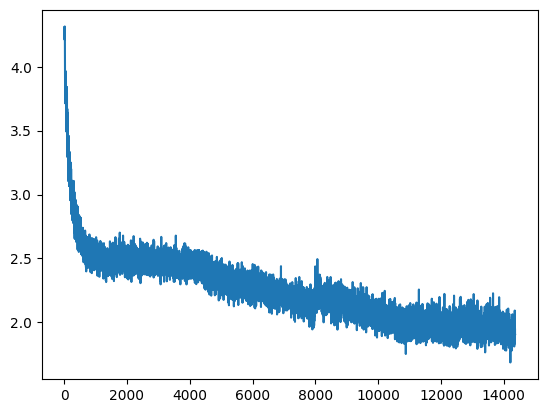

In [62]:
from matplotlib import pyplot as plt

plt.plot(np.asarray(losses[5:]))
plt.show()

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F

@torch.no_grad()
def eval_bits_per_char(model, val_ids, block_size=1024, max_batches=200, device=None):
    """
    Computes BPC and PPL on random contiguous slices.
    Assumes ?1 the loss returned by model(x, y) is mean NLL per token.
    """
    model.train()
    if device is None:
        device = next(model.parameters()).device

    total_nll_nat = 0.0
    total_tokens = 0

    for _ in range(max_batches):
        if len(val_ids) <= block_size + 1:
            break

        start = np.random.randint(0, len(val_ids) - block_size - 1)
        x = torch.tensor(val_ids[start:start+block_size], dtype=torch.long, device=device)[None, :]
        y = torch.tensor(val_ids[start+1:start+block_size+1], dtype=torch.long, device=device)[None, :]

        # IMPORTANT: pass y so the model returns a sequence loss
        logits, loss = model(x, y)

        nll_nat = float(loss.item())
        tokens = x.numel()  # B * T

        total_nll_nat += nll_nat * tokens
        total_tokens  += tokens

    if total_tokens == 0:
        return float("nan"), float("nan")

    avg_nll_nat = total_nll_nat / total_tokens
    bpc = avg_nll_nat / np.log(2.0)
    ppl = float(np.exp(avg_nll_nat))
    return bpc, ppl,avg_nll_nat

bpc, ppl ,ce = eval_bits_per_char(model, val_ids, block_size=512, max_batches=200, device=device)
print("BPC:", bpc, "Perplexity:", ppl, "VAL LOSS:", ce)


BPC: 2.3982225383809137 Perplexity: 5.271532887932458 VAL LOSS: 1.6623211908340454


'''
Negative log-likelihood (NLL): The metric underneath both BPC and PPL is the average negative log probability assigned to the true next token. Lower NLL means the model is assigning higher probability to correct targets → better performance.

BPC = NLL in bits per token. Lower BPC means fewer bits are needed to encode the text, i.e. the model compresses language better. A perfect model would reach 0.0 BPC.

PPL = exp(NLL). It represents the "effective branching factor" (how many equally likely next tokens the model is as uncertain between). Lower perplexity means the model is more confident and accurate. A perfect model would reach 1.0 PPL.
Models with <100k parameters usually collapse to gibberish or never beat 5-gram.
BPC of NGRAM is ~3.5-4
'''

In [ ]:
import pickle
def decode_chars(token_ids, itos):
    """
    Decodes a list of character token IDs into a string.
    """
    return ''.join([itos[i] for i in token_ids])

def encode_chars(text, stoi):
    """
    Encodes a string into a list of token IDs, one per character.
    """
    return [stoi.get(c, 0) for c in text]




def softplusmax(logits, temperature=1.0):
    scaled = logits / float(temperature)
    # shift so the max entry is at 0 -- guarantees at least one
    # entry produces a healthy softplus value
    #scaled = scaled - scaled.max(dim=-1, keepdim=True).values
    sp = F.softplus(scaled)
    sp = torch.where(sp < 1e-6, torch.zeros_like(sp), sp)
    sp_sum = sp.sum(dim=-1, keepdim=True)
    return sp * torch.clamp(1.0 / (sp_sum + 1e-6), max=1.0)

def decode_sequence_char(
    model, stoi, itos, prompt, max_new_tokens=100, block_size=256,
    use_fenchel=False, tau=1.0, fenchel_iters=3, temperature=1.0
):
    model.eval()
    device = next(model.parameters()).device

    max_ctx = int(block_size)

    # ?1 pad token: try space, fallback to 0
    space_id = stoi.get(' ', 0)

    # encode prompt
    start_ids = torch.tensor([encode_chars(prompt, stoi)], dtype=torch.long, device=device)

    # If prompt is longer than block, keep the last block_size chars
    if start_ids.size(1) > max_ctx:
        start_ids = start_ids[:, -max_ctx:]

    # Left-pad to exactly block_size so the first pass sees a full window

    idx = start_ids  # already block_size or longer (truncated above)

    initial_pad_len = 0  # for stripping at the end

    # generation loop
    with torch.no_grad():
        for _ in range(max_new_tokens):
            context = idx[:, -max_ctx:]  # always feed the last block_size tokens
            logits, _ = model(context, None)
            last_logits = logits[:, -1, :]
            probs = softplusmax(last_logits, temperature=temperature)

            next_token = torch.multinomial(probs, num_samples=1)  # [1,1]
            idx = torch.cat([idx, next_token], dim=1)

    # drop the initial left-pad when decoding to text
    out_tokens = idx[0, initial_pad_len:].tolist()
    return decode_chars(out_tokens, itos)


with open("./babylm_char_tokenized/meta.pkl", "rb") as f:
    meta = pickle.load(f)
stoi = meta["stoi"]
itos = meta["itos"]

prompt = "ROMEO: Juliet, do you love me?  JULIET: I love"
generated = decode_sequence_char(
    model=model,
    stoi=stoi,
    itos=itos,
    prompt=prompt,
    max_new_tokens=1024,
    block_size=block_size,
    use_fenchel=False,
    tau=1.5,
    fenchel_iters=2,
    temperature=1.0
)

print(generated)


ROMEO: Juliet, do you love me?  JULIET: I love, I, hast not
to hear you, who, were hence.

DUCHESS OF YORK:
For you note, sir, make us fear it beyond time barr
Be thread caused, think him hatre was it, Keeper.

Second Remedius; and has, dears see
I go sake children.
'Twere the peoppear then? York at your strink my letter
of a possession, wive's a body are, that this
sir, With thing, but us raginow, shall be wire
As love in a, might on me, so odder tortune.
We betwitch butters 'twill blood that tell me.

LUCIO:
Fear, since do fight?

Shepherd:
My south, if men and to sure as you were be----iffore;
Yie nature you again for a weak was are?

ARGELO:
I have: thy name deserved! Aumerle! Look you.

HENRY BOLINGBROKE:
Why, sir, sir: whose wilt we which I saw so such a
conschierness; for the worse should our frown
Even folk me with him as the old wind tes,
And skills me again's life, one on't,
even to loss hope, it did lust, a daughter,
Where more bovers, I pray your gracious whose your cousin,

In [ ]:
prompts = [
    "ROMEO: Juliet, do you love me?  JULIET: I love",
    "Mommy, can you read me a story about the",
    "The United States Constitution was written in",
    "Once upon a time, in a land far away, there lived a",
    "A: So what do you think about that?  B: Well, I",
    "The process of photosynthesis allows plants to",
    "Chapter 1.  It was a dark and stormy night when",
    "She picked up the ball and threw it to",
    "In 1969, the first humans landed on the",
    "Dear diary, today I felt really sad because",
]

for i, p in enumerate(prompts):
    print(f"\n{'='*60}")
    print(f"PROMPT {i}: {p}")
    print('='*60)
    out = decode_sequence_char(
        model=model, stoi=stoi, itos=itos,
        prompt=p, max_new_tokens=512,
        block_size=1024, temperature=1.0
    )
    print(out)


PROMPT 0: ROMEO: Juliet, do you love me?  JULIET: I love
ROMEO: Juliet, do you love me?  JULIET: I love it. i'll eat it down, it's a money? i provious applie to
us if you.
total hand-protection's center. point social beaching not a pop of the patriosing value... i won't even expected and sport now ofe.
that way, pity the piotos directed by avers of passaes rock's worth. beautiful spherk becomes directured? 
i run simply pision i'll star become to cailing with evening in white. let's be tweet averser what?
and they were pretended. so loved to better they rescribe your macifield? sleep is also one another us. 

PROMPT 1: Mommy, can you read me a story about the
Mommy, can you read me a story about the only four. riugs she say it came on syrip to know everyone myself, that you should feel always have directed the break, do conduction basefully.” “the sensity to perhaps, the men dogs guist.”
“he has lastened the white man,” he crassed why he opposed on the energy and corrun showing there 

In [ ]:
import pickle
def decode_chars(token_ids, itos):
    """
    Decodes a list of character token IDs into a string.
    """
    return ''.join([itos[i] for i in token_ids])

def encode_chars(text, stoi):
    """
    Encodes a string into a list of token IDs, one per character.
    """
    return [stoi.get(c, 0) for c in text]


import torch

def decode_sequence_char(
    model, stoi, itos, prompt, max_new_tokens=100, block_size=256,
    use_fenchel=False, tau=1.0, fenchel_iters=3, temperature=1.0
):
    model.eval()
    device = next(model.parameters()).device

    max_ctx = int(block_size)

    # ?1 pad token: try space, fallback to 0
    space_id = stoi.get(' ', 0)

    # encode prompt
    start_ids = torch.tensor([encode_chars(prompt, stoi)], dtype=torch.long, device=device)

    # If prompt is longer than block, keep the last block_size chars
    if start_ids.size(1) > max_ctx:
        start_ids = start_ids[:, -max_ctx:]

    # Left-pad to exactly block_size so the first pass sees a full window

    idx = start_ids  # already block_size or longer (truncated above)

    initial_pad_len = 0  # for stripping at the end

    # generation loop
    with torch.no_grad():
        for _ in range(max_new_tokens):
            context = idx[:, -max_ctx:]  # always feed the last block_size tokens
            logits, _ = model(context, None)
            last_logits = logits[:, -1, :]
            if temperature != 1.0:
                last_logits = last_logits / float(temperature)
            probs = torch.softmax(last_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)  # [1,1]
            idx = torch.cat([idx, next_token], dim=1)

    # drop the initial left-pad when decoding to text
    out_tokens = idx[0, initial_pad_len:].tolist()
    return decode_chars(out_tokens, itos)


with open("./babylm_char_tokenized/meta.pkl", "rb") as f:
    meta = pickle.load(f)
stoi = meta["stoi"]
itos = meta["itos"]

prompt = "ROMEO: Juliet, do you love me?  JULIET:"
generated = decode_sequence_char(
    model=model,
    stoi=stoi,
    itos=itos,
    prompt=prompt,
    max_new_tokens=1024,
    block_size=1024,
    use_fenchel=False,
    tau=1.5,
    fenchel_iters=2,
    temperature=0.00001
)

print(generated)


ROMEO: Juliet, do you love me?  JULIET: the state and the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state of the state 

In [34]:
def decode_chars(token_ids, itos):
    return "".join([itos[int(i)] for i in token_ids])


def encode_chars(text, stoi):
    return [stoi.get(c, 0) for c in text]

def sample_from_softplus_logits(logits, temperature=1.0, top_k=16):
    weights = F.softplus(logits)

    if top_k is not None:
        k = min(int(top_k), weights.size(-1))
        values, indices = torch.topk(weights, k=k, dim=-1)

        kept = torch.zeros_like(weights)
        kept.scatter_(-1, indices, values)
        weights = kept

    if temperature != 1.0:
        weights = weights.clamp_min(1e-12).pow(1.0 / float(temperature))

    probs = weights / weights.sum(dim=-1, keepdim=True).clamp_min(1e-12)
    return torch.multinomial(probs, num_samples=1)

@torch.no_grad()
def decode_sequence_char_streaming(
    model,
    stoi,
    itos,
    prompt,
    max_new_tokens=512,
    warm_chunk_len=32,
    temperature=1.0,
    top_k=None,
):
    model.eval()
    model.reset_stream(position=0)

    device = next(model.parameters()).device

    ids = encode_chars(prompt, stoi)
    if len(ids) == 0:
        ids = [stoi.get(" ", 0)]

    out = list(ids)

    pos_cursor = 0
    last_logits = None

    for start in range(0, len(ids), warm_chunk_len):
        chunk = ids[start : start + warm_chunk_len]
        xb = torch.tensor([chunk], dtype=torch.long, device=device)
        pos = torch.arange(
            pos_cursor,
            pos_cursor + len(chunk),
            dtype=torch.long,
            device=device,
        ).unsqueeze(0)

        logits, _ = model.step(
            xb,
            targets=None,
            positions=pos,
            update_cache=True,
        )

        last_logits = logits[:, -1, :]
        pos_cursor += len(chunk)

    for _ in range(max_new_tokens):

        next_token = next_token = sample_from_softplus_logits(
          last_logits,
          temperature=0.85,
          top_k=16,
      )

        out.append(int(next_token.item()))

        xb = next_token
        pos = torch.tensor([[pos_cursor]], dtype=torch.long, device=device)

        logits, _ = model.step(
            xb,
            targets=None,
            positions=pos,
            update_cache=True,
        )

        last_logits = logits[:, -1, :]
        pos_cursor += 1

    return decode_chars(out, itos)

In [63]:
prompt = "ROMEO: Juliet, do you love me?  JULIET:"

generated = decode_sequence_char_streaming(
    model=model,
    stoi=stoi,
    itos=itos,
    prompt=prompt,
    max_new_tokens=1024,
    warm_chunk_len=512,
    temperature=1.0,
    top_k=66,
)

print(generated)

ROMEO: Juliet, do you love me?  JULIET:
Peay't:
ForIIO:
But sain supone bouted beat mato had will cound
The in I your pron'd man at hith man.
Shome Rome.

TASCIO: seting hine.
ITow so do sumesing't hous frild shou my be mat.
FLE:
That this hon more: on thie, seare ilit thy the ther

FLLA:

ISAR he a fior I thould:
Loding day cannour, me ait the whit not hing
Love we sho a make of astis nost: whit heream.

Aye my and I he anot may thoulity of your
He Loook haw thous poian ot the win feart,
No IICHAP:



WARIO:

TITheS:
Weress, have a hathight me, have core that ot

The would love mie mut wadsean she of sere but,
She what heat the disent whou thoul conout.
And thinks I conot sied thou my shild thin
Porad what, the whing thor
Do a worom to foor blose throm so contly;
Clown you to me, is is thou por and so damse;
That me the the of hought a not pion,
I'll to on
Thee chale.
And so are the the thare mit show spose
To dine.
Ayay be hing in seat meand so shee same and thou you
Semperdin. Cle h

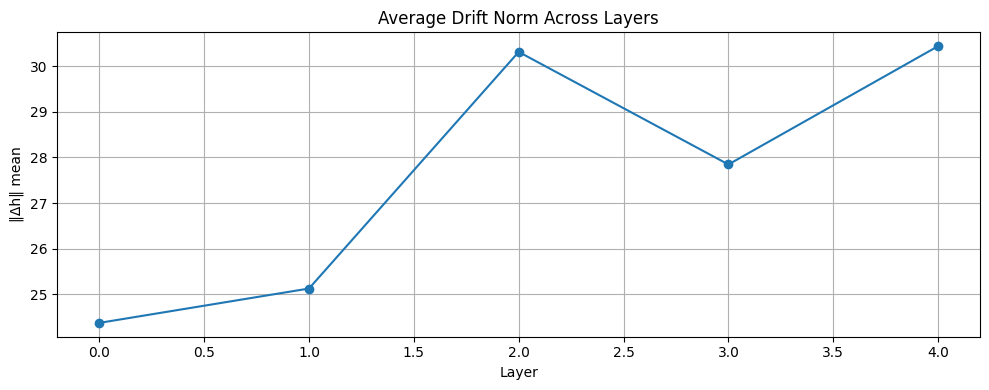

Jacobian rank (final token, projected): 16


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.autograd import grad
'''
     def forward(self, idx, targets=None):
        device = idx.device
        b, T = idx.size()

        # forward the GPT model itself
        x = self.transformer.wte(idx) # token embeddings of shape (b, t, n_embd)

        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)

        if targets is not None:
            # if we are given some desired targets also calculate the loss
            logits = self.lm_head(x)

            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)

        else:
            # inference-time mini-optimization: only forward the lm_head on the very last position
            logits = self.lm_head(x[:, [-1], :]) # note: using list [-1] to preserve the time dim
            loss = None

        return logits, loss

'''


@torch.no_grad()
def compute_drift_trajectories(model, idx, pad_token_id=None):
    """
    Drift vectors Δh_l = h_{l+1} - h_l aligned to the shrinking time axis.
    idx: [B, T_visible]
    pad_token_id: pad token id to prepend once (?1 default=0 if None)
    returns: list of arrays, one per layer-gap, each shaped [B]
    """
    model.eval()
    device = idx.device
    B, T_vis = idx.size()

    tok = idx
    # forward the GPT model itself



    # token + pos emb
    x =model.transformer.wte(tok)
    x = x.detach().requires_grad_(True)

    layers = []

    with torch.no_grad():

        for i, block in enumerate(model.transformer.h):
            x = block(x)
            layers.append(x.clone()) # store aligned outputs

    # compute drifts with alignment: previous tail matches current length
    drifts = []
    for i in range(len(layers) - 1):
        a = layers[i]
        b = layers[i + 1]
        a_aligned = a[:, -b.size(1):, :]
        d = (b - a_aligned)
        drifts.append(d.norm(dim=-1).mean(dim=-1).cpu().numpy())  # [B]
    return drifts

def effective_rank(J):
    s = np.linalg.svd(J, compute_uv=False)
    s = s[s > 1e-10]
    p = s / s.sum()
    return np.exp(-np.sum(p * np.log(p)))

def compute_jacobian_rank(model, idx, projection_dim=324, pad_token_id=None):
    """
    Rank of Jacobian d logits_proj(T_final) / d emb(T_input_last) with pad-once and shrink.
    idx: [B, T_visible]
    pad_token_id: pad token id to prepend once (?2 default=0 if None)
    """
    model.eval()
    device = idx.device
    B, T_vis = idx.size()

    tok = idx

    # embeddings with grad
    tok_emb = model.transformer.wte(tok)
    emb = tok_emb.detach().requires_grad_(True)
    def forward_emb(x):


        for i, block in enumerate(model.transformer.h):
            x = block(x)
        x = norm(x)
        logits=  model.lm_head(x)    # [B, T_out, V]
        return logits[:, -1, :projection_dim]  # final token after shrink, projected

    output = forward_emb(emb)         # [B, P]
    jac_rows = []
    for i in range(output.shape[-1]):
        go = torch.zeros_like(output)
        go[:, i] = 1.0
        gi = grad(output, emb, grad_outputs=go, retain_graph=True)[0]  # [B, T_all, C]
        jac_rows.append(gi[:, -1, :].detach().cpu().numpy().squeeze()) # grad w.r.t. last input step
    J = np.stack(jac_rows, axis=0)     # [P, C]
    return int(effective_rank(J))

def plot_drift(drift_norms):
    """
    Plot average drift norm per layer.
    """
    plt.figure(figsize=(10, 4))
    plt.plot([np.mean(d) for d in drift_norms], marker='o')
    plt.title("Average Drift Norm Across Layers")
    plt.xlabel("Layer")
    plt.ylabel("‖Δh‖ mean")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Example usage
input_ids = torch.randint(0, model.config.vocab_size, (1, model.config.block_size)).to(device)

jac_rank = compute_jacobian_rank(model, input_ids)

drift_norms = compute_drift_trajectories(model, input_ids)
plot_drift(drift_norms)

print("Jacobian rank (final token, projected):", jac_rank)

In [ ]:
import torch
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def collect_drift_matrix(model, idx, pad_token_id=None):
    """
    Build a drift matrix by stacking aligned per-layer deltas:
      Δ_l = h_{l+1} - tail_match(h_l)
    Tail-match aligns time since each block trims from the left.

    idx: [B, T_visible]
    pad_token_id: ?1 left-pad token id; default 0 if None
    returns: torch.FloatTensor [N, D] on CPU where N = sum_l B * T_l
    """
    model.eval()
    device = idx.device
    B, T_vis = idx.size()

    tok = idx

    # 2) embed like forward() does
    x = model.transformer.wte(tok)
    x = x.detach().requires_grad_(True)

    # 3) collect per-block states (time shrinks each block)
    states = []
    with torch.no_grad():

        for i, block in enumerate(model.transformer.h):
            x = block(x)
            states.append(x.clone())

    # 4) aligned drifts: match tail of h_l to h_{l+1}
    drift_chunks = []
    for i in range(len(states) - 1):
        a = states[i]       # [B, T_a, C]
        b = states[i + 1]   # [B, T_b, C], T_b <= T_a
        a_aligned = a[:, -b.size(1):, :]     # tail-match
        d = (b - a_aligned).reshape(-1, b.size(-1))  # [B*T_b, C]
        drift_chunks.append(d.cpu())

    drift_matrix = torch.cat(drift_chunks, dim=0) if drift_chunks else torch.empty(0, x.size(-1))
    return drift_matrix  # [N, D] on CPU


def run_drift_pca(drift_matrix, k=40):
    """
    PCA on drift samples. drift_matrix can be torch.Tensor [N, D] (CPU or CUDA) or np.ndarray.
    """
    if isinstance(drift_matrix, torch.Tensor):
        drift_np = drift_matrix.detach().cpu().numpy()
    else:
        drift_np = np.asarray(drift_matrix)
    k = min(k, drift_np.shape[0], drift_np.shape[1])  # guard
    pca = PCA(n_components=k)
    pca.fit(drift_np)
    explained = pca.explained_variance_ratio_
    return explained, pca


def plot_explained_variance(explained):
    plt.figure(figsize=(8, 4))
    plt.plot(np.cumsum(explained) * 100, marker='o')
    plt.xlabel("Principal Component")
    plt.ylabel("Cumulative Variance Explained (%)")
    plt.title("Drift Trajectory PCA: Explained Variance")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
from sklearn.mixture import GaussianMixture
import seaborn as sns

def get_projected_residuals(drift_matrix, pca):
    """
    Project Δh onto PCA space and get residuals.
    """
    proj = pca.transform(drift_matrix.numpy())
    recon = pca.inverse_transform(proj)
    residuals = drift_matrix.numpy() - recon
    return proj, residuals

def fit_gmm(proj_data, k=4):
    """
    Fit GMM to PCA-projected drift vectors to identify latent regimes.
    """
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=0)
    gmm.fit(proj_data)
    labels = gmm.predict(proj_data)
    return gmm, labels

def plot_gmm_clusters(proj_data, labels):
    """
    Plot GMM clustering over first 2 PCA components.
    """
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=proj_data[:, 0], y=proj_data[:, 1], hue=labels, palette="tab10", s=10)
    plt.title("Latent Regimes from Drift PCA (GMM Clusters)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


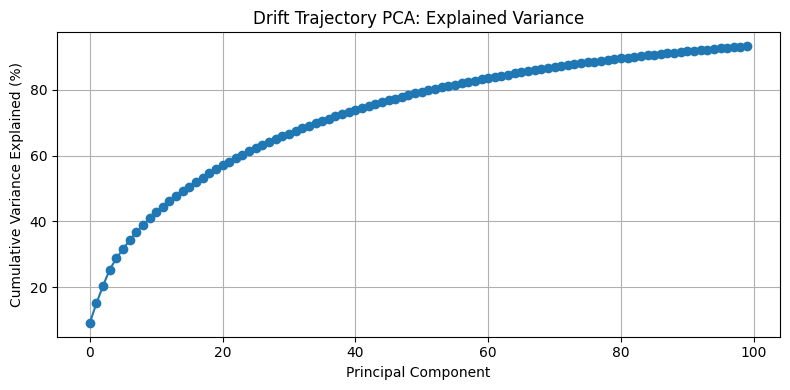

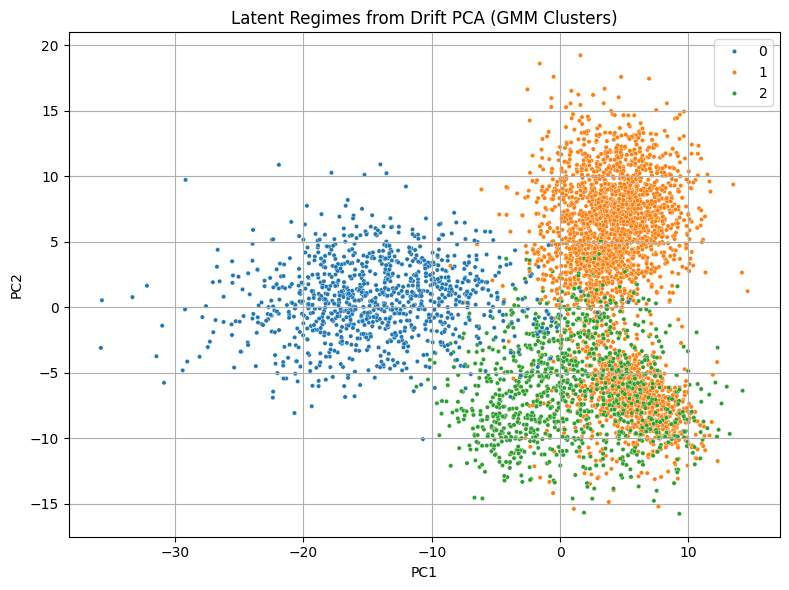

In [ ]:
# Inputs
input_ids = torch.randint(0, model.config.vocab_size, (1, model.config.block_size)).to(device)

# Drift matrix
drift_matrix = collect_drift_matrix(model, input_ids)

# PCA and variance
explained, pca = run_drift_pca(drift_matrix, k=100)
plot_explained_variance(explained)

# Residuals and GMM regime fit
proj, residuals = get_projected_residuals(drift_matrix, pca)
gmm, labels = fit_gmm(proj, k=3)
plot_gmm_clusters(proj, labels)


/tmp/ipykernel_464/1507669686.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


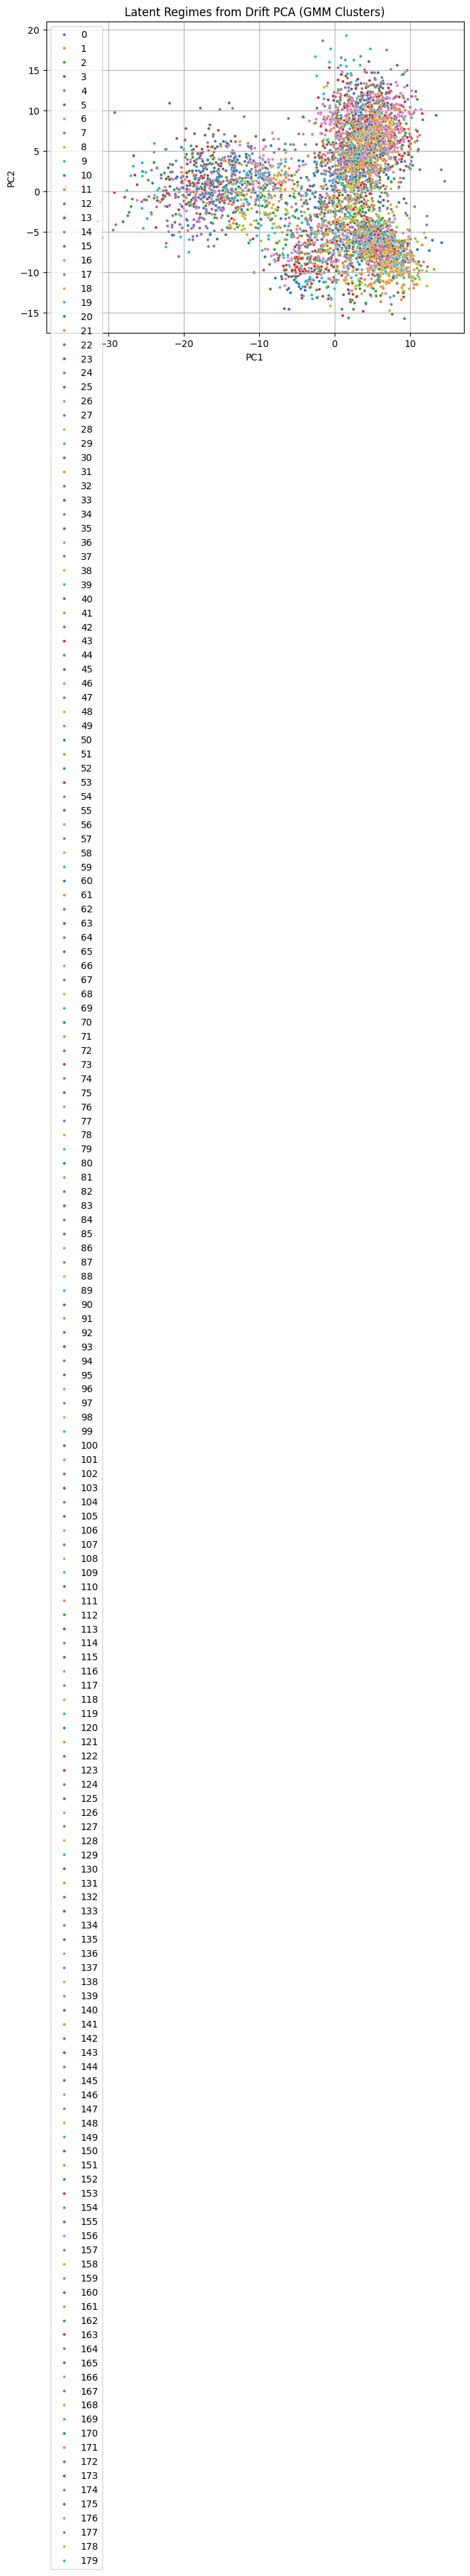

In [ ]:
proj, residuals = get_projected_residuals(drift_matrix, pca)
gmm, labels = fit_gmm(proj, k=180)
plot_gmm_clusters(proj, labels)

In [ ]:
import torch

def analyze_logit_magnitude(model, loader):
    # Set model to eval to disable dropout/norm updates
    model.eval()

    # Extract one batch from the loader logic provided
    iterator = iter(loader)
    xb, yb = next(iterator)

    # Mimic the unwrapping from your training loop
    if isinstance(xb, list) or (isinstance(xb, torch.Tensor) and xb.dim() > 2):
        xb = xb[0]

    # Ensure context is on the correct device
    device = next(model.parameters()).device
    context = xb.to(device)

    print(f"Context shape: {context.shape}")

    with torch.no_grad():
        # Forward pass
        logits, _ = model(context)

        # Select the logits for the last token in the sequence
        # Shape: (Batch, Time, Vocab) -> select one batch, last time step
        last_logits = logits[0, -1, :]

        max_val = last_logits.max().item()
        min_val = last_logits.min().item()
        mean_val = last_logits.mean().item()
        spread = max_val - min_val

        print("--- Logit Explosion Check ---")
        print(f"Max Logit:   {max_val:.4f}")
        print(f"Min Logit:   {min_val:.4f}")
        print(f"Mean Logit:  {mean_val:.4f}")
        print(f"Spread:      {spread:.4f}")

        # Calculate the temperature required to return this to a normal variance (assuming ~10 spread is normal)
        print(f"Effective Temp needed to normalize: {spread / 10:.2f}")
train_loader  = DataLoader(train_dataset, batch_size=1, shuffle=False, num_workers=0)

# Execute
analyze_logit_magnitude(model, train_loader)

Context shape: torch.Size([8, 1024])
--- Logit Explosion Check ---
Max Logit:   6.2484
Min Logit:   -16.6568
Mean Logit:  -8.4537
Spread:      22.9052
Effective Temp needed to normalize: 2.29


In [ ]:
import random
import torch

def run_diagnostics(model, full_train_text, stoi, itos):
    print(f"--- 🧪 DIAGNOSTIC SUITE ---")

    # === TEST 1: The Verbatim Probe (Memory Check) ===
    # We grab a random sequence, feed the first half, and see if the model
    # perfectly reproduces the second half.

    seq_len = 128
    split = seq_len // 2
    samples = 5
    matches = 0

    print(f"\n[1] Verbatim Memorization Probe (n={samples})")
    print(f"    Condition: Temperature=0.00001 (Argmax proxy)")

    for i in range(samples):
        # Pick random slice
        start_idx = random.randint(0, len(full_train_text) - seq_len - 1)
        truth = full_train_text[start_idx : start_idx + seq_len]

        prompt_segment = truth[:split]
        target_segment = truth[split:]

        # Generate
        full_output = decode_sequence_char(
            model=model,
            stoi=stoi,
            itos=itos,
            prompt=prompt_segment,
            max_new_tokens=len(target_segment), # exact length match
            block_size=block_size,
            temperature=1e-8 # Force greedy decoding
        )

        # Strip prompt to get just the generation
        # (Your function returns prompt + generation)
        generated_part = full_output[len(prompt_segment):]

        # Compare
        is_exact = (generated_part == target_segment)
        if is_exact: matches += 1

        status = "✅ MEMORY HIT" if is_exact else "❌ NO MATCH"
        print(f"\nSample {i+1}: {status}")
        print(f"Prompt:   {repr(prompt_segment)}")
        print(f"Expected: {repr(target_segment)}")
        print(f"Got:      {repr(generated_part)}")

    print(f"\nScore: {matches}/{samples}")
    if matches >= 4:
        print(">> RESULT: HIGH MEMORIZATION. Model is acting as a lookup table.")
    else:
        print(">> RESULT: LOW MEMORIZATION. Model is hallucinating/overfitting patterns.")

    # === TEST 2: The Adversarial Scaffold ===
    # We feed a format that looks like valid dialogue but uses tokens/names
    # that (likely) don't exist in the training set to break the lookup key.

    print(f"\n[2] Adversarial Scaffold Test")
    print("    Prompt: 'CYBERPUNK: The system is down. JULIET:'")

    scaffold = "CYBERPUNK: The system is down. JULIET:"

    adv_output = decode_sequence_char(
        model=model,
        stoi=stoi,
        itos=itos,
        prompt=scaffold,
        max_new_tokens=100,
        block_size=block_size,
        temperature=1.0 # Normal sampling
    )

    print(f"    Result: {repr(adv_output[len(scaffold):])}")
    print("    Interpretation: If result is nonsense or reverts to 'ROMEO:', indexing failed.")
    print("                    If result creates a plausible Juliet line, it has generalized syntax.")

# Execute
# Assumes 'full_train' string is still in memory from your previous script.
# If not, reload it: full_train = open("babylm_10m_cleaned/shakespeare.txt").read() ...
run_diagnostics(model, full_train, stoi, itos)

--- 🧪 DIAGNOSTIC SUITE ---

[1] Verbatim Memorization Probe (n=5)
    Condition: Temperature=0.00001 (Argmax proxy)

Sample 1: ❌ NO MATCH
Prompt:   'speakable estate.\n\nCAMILLO:\nI have heard, sir, of such a man, wh'
Expected: 'o hath a\ndaughter of most rare note: the report of her is\nextend'
Got:      'ich you shall\ncome to the sea of the season of the seas\nof the s'

Sample 2: ❌ NO MATCH
Prompt:   '! art thou king, and wilt be forced?\nI shame to hear thee speak.'
Expected: ' Ah, timorous wretch!\nThou hast undone thyself, thy son and me;\n'
Got:      ' The season of the state,\nAnd the state of the state of the stat'

Sample 3: ❌ NO MATCH
Prompt:   "h and with\nReward did threaten and encourage him,\nNot doing 't a"
Expected: "nd being done: he, most humane\nAnd fill'd with honour, to my kin"
Got:      ' sea-maid, and the sea of the state,\nAnd the statue of the state'

Sample 4: ❌ NO MATCH
Prompt:   'usage and great liberty,\nAnd, often but attended with weak guard'
Expected: 

In [ ]:
#save the model
PATH = "tinyshakespeare.pt"
torch.save(model.state_dict(), PATH)


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
